In [11]:

!pip install -q PySastrawi wordcloud openpyxl vaderSentiment

print("✅ Instalasi selesai.")

✅ Instalasi selesai.


In [12]:
# IMPORT GDRIVE
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [13]:
# ┌─────────────────────────────────────────────────────────────────────────┐
# │ CELL 2  ─  IMPORT & KONFIGURASI GLOBAL                                  │
# └─────────────────────────────────────────────────────────────────────────┘
# %%

import os, re, time, math, json, warnings, ast
from collections import Counter
from IPython.display import display

import numpy  as np
import pandas as pd
import matplotlib.pyplot   as plt
import matplotlib.patches  as mpatches
import seaborn as sns
from wordcloud import WordCloud

# ── sklearn ──────────────────────────────────────────────────────────────
from sklearn.svm            import SVC
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import (
    train_test_split, GridSearchCV,
    StratifiedKFold, cross_val_predict
)
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score, precision_score, recall_score
)
from sklearn.pipeline import Pipeline

# ── NLP ──────────────────────────────────────────────────────────────────
import nltk
from nltk.tokenize        import word_tokenize
from nltk.sentiment.vader import SentimentIntensityAnalyzer   # dipakai load InSet
from Sastrawi.Stemmer.StemmerFactory             import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

nltk.download("punkt",     quiet=True)
nltk.download("punkt_tab", quiet=True)
nltk.download("vader_lexicon", quiet=True)
warnings.filterwarnings("ignore")

# ── Palet warna konsisten ─────────────────────────────────────────────────
PAL = {
    "positif"  : "#2E7D32",
    "negatif"  : "#C62828",
    "netral"   : "#546E7A",
    "primary"  : "#1565C0",
    "secondary": "#F57F17",
    "bg"       : "#FAFAFA",
}

# ── Direktori output ──────────────────────────────────────────────────────
OUTPUT_DIR = "/content/output_hasil"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── Konstanta ─────────────────────────────────────────────────────────────
RANDOM_STATE = 42
TEXT_COL     = "text"   # ← sesuaikan nama kolom tweet Anda
DATE_COL     = "createdAt"   # ← kolom tanggal (opsional, kosongkan jika tidak ada)
TFIDF_MAX    = 10_000
SPLITS       = {"70:30": 0.30, "80:20": 0.20, "90:10": 0.10}
KFOLD_LIST   = [5, 10, 15, 20]

# URL dictionary dari GitHub (persis sama seperti referensi lailikanabila)
URL_KAMUS_ALAY  = "/content/drive/MyDrive/svm_dpr/kamusalay.csv"
URL_STOPWORDS   = "/content/drive/MyDrive/svm_dpr/stopword.txt"
print("SW:", os.path.exists(URL_KAMUS_ALAY))
print("SLANG:", os.path.exists(URL_STOPWORDS))
print("✅ Import & konfigurasi selesai.")

SW: True
SLANG: True
✅ Import & konfigurasi selesai.


In [14]:
# ┌─────────────────────────────────────────────────────────────────────────┐
# │ CELL 3  ─  DOWNLOAD DICTIONARY DARI GITHUB (persis referensi)           │
# │                                                                          │
# │  • Colloquial Indonesian Lexicon → nasalsabila/kamus-alay               │
# │  • ID-Stopwords                  → masdevid/ID-Stopwords                │
# └─────────────────────────────────────────────────────────────────────────┘
# %%

print("📥 Mengunduh Dictionary dari GitHub (sama persis seperti referensi) ...")

# ── 1. Kamus Alay (Colloquial Indonesian Lexicon) ─────────────────────────
# File: colloquial-indonesian-lexicon.csv
# Kolom: 'slang' dan 'formal'  (3.592 entri kata alay → formal)
df_alay  = pd.read_csv(URL_KAMUS_ALAY)
# Kolom berbeda tiap versi CSV, normalkan
col_slang  = df_alay.columns[0]   # kolom pertama = kata slang
col_formal = df_alay.columns[1]   # kolom kedua   = kata formal
slang_dict = dict(zip(
    df_alay[col_slang].astype(str).str.lower().str.strip(),
    df_alay[col_formal].astype(str).str.lower().str.strip()
))
print(f"   ✅ Kamus Alay       : {len(slang_dict):,} entri "
      f"(nasalsabila/kamus-alay)")

# ── 2. ID-Stopwords ────────────────────────────────────────────────────────
# File: id.stopwords.02.01.2016.txt (satu kata per baris)
import urllib.request
# Changed from urllib.request.urlopen to open() for local file
with open(URL_STOPWORDS, 'r', encoding='utf-8') as resp:
    id_stopwords_github = set(
        line.strip().lower()
        for line in resp if line.strip()
    )

# Gabungkan dengan stopwords Sastrawi (seperti di notebook 3 referensi)
sastrawi_sw = set(StopWordRemoverFactory().get_stop_words())
ALL_STOPWORDS = id_stopwords_github | sastrawi_sw

# Tambahan stopwords domain-spesifik DPR RI (bukan dari GitHub, tapi relevan)
domain_sw = {
    "dpr","ri","dewan","perwakilan","rakyat","republik","indonesia",
    "tweet","twitter","x","rt","via","amp","pic","https","http",
}
ALL_STOPWORDS = ALL_STOPWORDS | domain_sw

print(f"   ✅ ID-Stopwords     : {len(id_stopwords_github):,} kata "
      f"(masdevid/ID-Stopwords)")
print(f"   ✅ Sastrawi SW      : {len(sastrawi_sw):,} kata")
print(f"   ✅ Total stopwords  : {len(ALL_STOPWORDS):,} kata (gabungan)")
print(f"\n✅ Semua dictionary berhasil diunduh dari GitHub.")

📥 Mengunduh Dictionary dari GitHub (sama persis seperti referensi) ...
   ✅ Kamus Alay       : 4,330 entri (nasalsabila/kamus-alay)
   ✅ ID-Stopwords     : 757 kata (masdevid/ID-Stopwords)
   ✅ Sastrawi SW      : 809 kata
   ✅ Total stopwords  : 830 kata (gabungan)

✅ Semua dictionary berhasil diunduh dari GitHub.


In [15]:
# ┌─────────────────────────────────────────────────────────────────────────┐
# │ CELL 4  ─  UPLOAD FILE DATA & INSET LEXICON                             │
# └─────────────────────────────────────────────────────────────────────────┘
# %%

from google.colab import files

EXCEL_PATH  = "/content/drive/MyDrive/svm_dpr/DataClean.csv"

POS_PATH="/content/drive/MyDrive/svm_dpr/positive.tsv"
NEG_PATH="/content/drive/MyDrive/svm_dpr/negative.tsv"

print("DATA:", os.path.exists(EXCEL_PATH))
print("INSET POS:", os.path.exists(POS_PATH))
print("INSET NEG:", os.path.exists(NEG_PATH))
print("\n✅ File berhasil diupload.")

DATA: True
INSET POS: True
INSET NEG: True

✅ File berhasil diupload.


In [16]:
# ===========================================================
# BAB IV
# 4.1 Audit Dataset
# ===========================================================

In [17]:
import os

OUTPUT = "/content/drive/MyDrive/svm_dpr/HASIL_SKRIPSI"

os.makedirs(OUTPUT, exist_ok=True)

print("Folder output:")
print(OUTPUT)

Folder output:
/content/drive/MyDrive/svm_dpr/HASIL_SKRIPSI


In [19]:
print("="*60)
print("STATISTIK DATASET")
print("="*60)

print(f"Jumlah Tweet      : {len(df_raw)}")
print(f"Jumlah Kolom      : {df_raw.shape[1]}")
print(f"Missing Value     : {df_raw.isnull().sum().sum()}")
print(f"Duplicate         : {df_raw.duplicated().sum()}")

print("\nDaftar Kolom")

for col in df_raw.columns:
    print("-",col)

STATISTIK DATASET
Jumlah Tweet      : 5000
Jumlah Kolom      : 16
Missing Value     : 4844
Duplicate         : 0

Daftar Kolom
- id
- text
- createdAt
- retweetCount
- replyCount
- likeCount
- quoteCount
- viewCount
- bookmarkCount
- lang
- isReply
- isQuote
- year_month
- word_count
- char_count
- text_clean


In [21]:
statistik = pd.DataFrame({

"Parameter":[

"Jumlah Tweet",

"Jumlah Kolom",

"Missing Value",

"Duplicate"

],

"Nilai":[

len(df_raw),

df_raw.shape[1],

df_raw.isnull().sum().sum(),

df_raw.duplicated().sum()

]

})

display(statistik)

statistik.to_excel(

OUTPUT+"/Tabel_4_1_StatistikDataset.xlsx",

index=False

)

,Parameter,Nilai
0,Jumlah Tweet,5000
1,Jumlah Kolom,16
2,Missing Value,4844
3,Duplicate,0


In [23]:
df_raw["createdAt"] = pd.to_datetime(df_raw["createdAt"])

bulanan = (
    df_raw
    .groupby(df_raw["createdAt"].dt.to_period("M"))
    .size()
    .reset_index(name="Jumlah Tweet")
)

display(bulanan)

bulanan.to_excel(
    OUTPUT+"/Tabel_4_2_DistribusiBulanan.xlsx",
    index=False
)

,createdAt,Jumlah Tweet
0,2025-11,717
1,2025-12,626
2,2026-01,681
3,2026-02,620
4,2026-03,506
5,2026-04,641
6,2026-05,650
7,2026-06,559


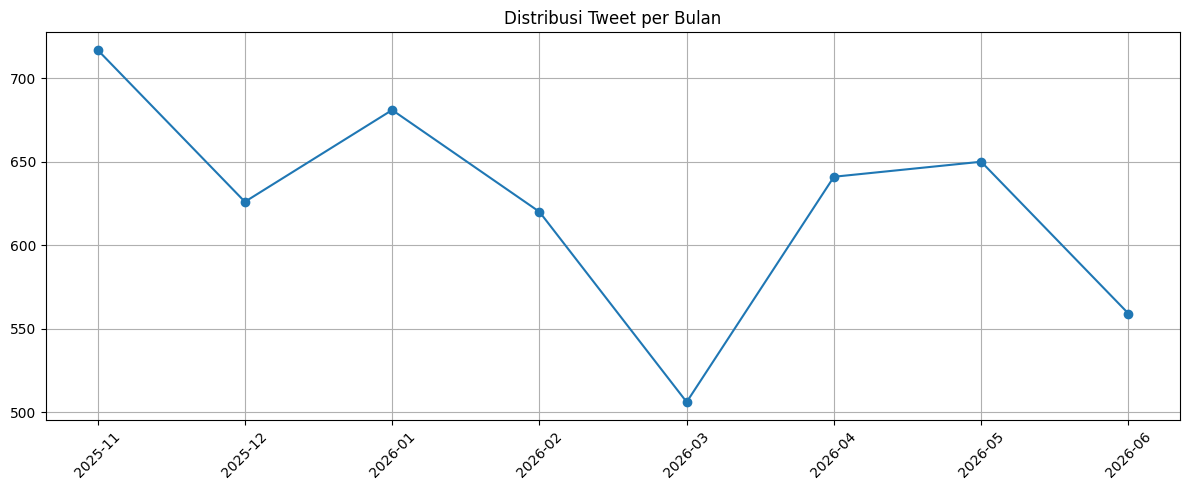

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.plot(
    bulanan["createdAt"].astype(str),
    bulanan["Jumlah Tweet"],
    marker="o"
)

plt.xticks(rotation=45)

plt.title("Distribusi Tweet per Bulan")

plt.grid(True)

plt.tight_layout()

plt.savefig(
    OUTPUT+"/Gambar_4_1_DistribusiTweet.png",
    dpi=300
)

plt.show()

In [27]:
sample = df_raw[
    ["createdAt","text"]
].head(20)

display(sample)

sample.to_csv(
    OUTPUT+"/Tabel_4_3_SampelDataset.csv",
    index=False
)

,createdAt,text
0,2026-01-29 01:00:40+00:00,Anggota Komisi III DPR RI dari Fraksi PDI-P Sa...
1,2026-02-23 06:33:22+00:00,Komisi III DPR RI mengingatkan majelis hakim P...
2,2026-03-09 18:56:32+00:00,"Mulan DPR Lulusan SMA? Tunggu, Cek Dulu Pendid..."
3,2025-12-30 06:56:27+00:00,Benarkah revisi UUP2SK membuat exchange lokal ...
4,2025-11-13 03:41:42+00:00,"Ketua DPR RI, Puan Maharani, menghadiri forum ..."
5,2025-11-20 11:55:58+00:00,Badan Legislasi (Baleg) DPR RI mengadakan Rapa...
6,2025-11-13 10:30:00+00:00,Komisi III DPR RI akan menggelar sidang pengam...
7,2026-02-14 06:55:44+00:00,Wakil Ketua Komisi XII DPR RI Sugeng Suparwoto...
8,2026-02-09 07:10:00+00:00,DPR RI bersama pemerintah memastikan layanan k...
9,2026-01-26 13:42:50+00:00,KOMISI XI DPR RI resmi menetapkan Wakil Menter...


In [28]:
import pandas as pd
# ┌─────────────────────────────────────────────────────────────────────────┐
# │ CELL 5  ─  NB-2: CLEANSING TEXT                                         │
# │  (Persis seperti notebook 2 referensi lailikanabila)                    │
# │  Urutan: hapus duplikat → regex cleansing → lowercase                   │
# └─────────────────────────────────────────────────────────────────────────┘
# %%

print("=" * 65)
print("  NB-2 : CLEANSING TEXT")
print("=" * 65)

# ── Load data ─────────────────────────────────────────────────────────────
df_raw = pd.read_csv(EXCEL_PATH)
print(f"📥 Data awal        : {len(df_raw):,} baris")
print(f"   Kolom            : {list(df_raw.columns)}")

# ── Step 1: Hapus duplikat (persis referensi NB-2) ───────────────────────
before = len(df_raw)
df_raw = df_raw.drop_duplicates(subset=[TEXT_COL]).reset_index(drop=True)
print(f"🗑️  Hapus duplikat   : {before - len(df_raw):,} dihapus "
      f"→ sisa {len(df_raw):,} baris")

# ── Fungsi cleansing (persis regex referensi NB-2) ────────────────────────
def cleansing(text: str) -> str:
    text = str(text)
    text = re.sub(r"@[A-Za-z0-9_]+"   , " ", text)   # hapus mention @user
    text = re.sub(r"#[A-Za-z0-9_]+"   , " ", text)   # hapus hashtag
    text = re.sub(r"http\S+|www\S+"   , " ", text)   # hapus URL
    text = re.sub(r"RT[\s]+"          , " ", text)   # hapus RT
    text = re.sub(r"&[a-z]+;"         , " ", text)   # hapus HTML entity (&amp; dll)
    text = re.sub(r"[^\x00-\x7F]+"   , " ", text)   # hapus emoji/non-ASCII
    text = re.sub(r"\d+"              , " ", text)   # hapus angka
    text = re.sub(r"[^a-zA-Z\s]"     , " ", text)   # hapus tanda baca & karakter spesial
    text = re.sub(r"\s+"              , " ", text).strip()
    return text

def casefolding(text: str) -> str:
    return text.lower()

# ── Terapkan cleansing ────────────────────────────────────────────────────
df_raw["text_clean"] = df_raw[TEXT_COL].apply(lambda x: casefolding(cleansing(x)))

# Simpan teks kosong setelah cleansing
before = len(df_raw)
df_raw = df_raw[df_raw["text_clean"].str.strip() != ""].reset_index(drop=True)
print(f"🧹 Setelah cleansing : {len(df_raw):,} baris "
      f"(hapus {before - len(df_raw):,} baris kosong)")

# ── TABEL 7: Ilustrasi preprocessing 1 tweet (before/after tiap tahap) ───
sample_orig  = str(df_raw[TEXT_COL].iloc[0])
s_clean      = cleansing(sample_orig)
s_case       = casefolding(s_clean)

steps_nb2 = pd.DataFrame({
    "No"  : ["1","2","3"],
    "Tahap" : ["Teks Asli", "Cleansing (hapus mention/URL/hashtag/emoji/angka/tanda baca)",
               "Casefolding (semua huruf kecil)"],
    "Hasil" : [sample_orig, s_clean, s_case],
})
print("\n📋 TABEL NB-2: CLEANSING (1 Tweet Sampel)")
display(
    steps_nb2.style
    .set_properties(**{"text-align":"left","white-space":"pre-wrap","max-width":"700px"})
    .set_table_styles([
        {"selector":"th","props":[("background",PAL["primary"]),("color","white"),
                                  ("text-align","left")]},
        {"selector":"tr:nth-child(even)","props":[("background","#EEF2FF")]},
    ])
    .hide(axis="index")
)
steps_nb2.to_excel(f"{OUTPUT_DIR}/tabel_nb2_cleansing.xlsx", index=False)
print("✅ NB-2 Cleansing selesai.")

  NB-2 : CLEANSING TEXT
📥 Data awal        : 5,000 baris
   Kolom            : ['id', 'text', 'createdAt', 'retweetCount', 'replyCount', 'likeCount', 'quoteCount', 'viewCount', 'bookmarkCount', 'lang', 'isReply', 'isQuote', 'year_month', 'word_count', 'char_count']
🗑️  Hapus duplikat   : 0 dihapus → sisa 5,000 baris
🧹 Setelah cleansing : 5,000 baris (hapus 0 baris kosong)

📋 TABEL NB-2: CLEANSING (1 Tweet Sampel)


No,Tahap,Hasil
1,Teks Asli,"Anggota Komisi III DPR RI dari Fraksi PDI-P Safaruddin mencecar Kapolres Sleman Kombes Pol Edy Setyanto Erning Wibowo terkait penanganan kasus Hogi Minaya, suami korban penjambretan yang ditetapkan sebagai tersangka usai mengejar pelaku hingga meninggal dunia. + #Polisi #DPR ##Cut"
2,Cleansing (hapus mention/URL/hashtag/emoji/angka/tanda baca),Anggota Komisi III DPR RI dari Fraksi PDI P Safaruddin mencecar Kapolres Sleman Kombes Pol Edy Setyanto Erning Wibowo terkait penanganan kasus Hogi Minaya suami korban penjambretan yang ditetapkan sebagai tersangka usai mengejar pelaku hingga meninggal dunia
3,Casefolding (semua huruf kecil),anggota komisi iii dpr ri dari fraksi pdi p safaruddin mencecar kapolres sleman kombes pol edy setyanto erning wibowo terkait penanganan kasus hogi minaya suami korban penjambretan yang ditetapkan sebagai tersangka usai mengejar pelaku hingga meninggal dunia


✅ NB-2 Cleansing selesai.


In [29]:
# ┌─────────────────────────────────────────────────────────────────────────┐
# │ CELL 6  ─  NB-3: SLANGWORD & STOPWORD                                   │
# │  (Persis seperti notebook 3 referensi lailikanabila)                    │
# │  Urutan: tokenizing → normalisasi slang → stopword removal → stemming   │
# └─────────────────────────────────────────────────────────────────────────┘
# %%

print("=" * 65)
print("  NB-3 : SLANGWORD & STOPWORD")
print("=" * 65)

stemmer = StemmerFactory().create_stemmer()

def tokenizing(text: str) -> list:
    """Tokenisasi dengan word_tokenize (NLTK)."""
    return word_tokenize(text)

def normalize_slang(tokens: list, slang_dict: dict) -> list:
    """Normalisasi kata alay menggunakan Colloquial Indonesian Lexicon."""
    return [slang_dict.get(t, t) for t in tokens]

def remove_stopwords(tokens: list, sw: set) -> list:
    """Hapus stopwords menggunakan ID-Stopwords + Sastrawi."""
    return [t for t in tokens if t not in sw and len(t) > 1]

def stemming_tokens(tokens: list, stemmer) -> list:
    """Stemming menggunakan Sastrawi."""
    return [stemmer.stem(t) for t in tokens]

def nb3_pipeline(text: str) -> str:
    """Pipeline NB-3: tokenize → slang → stopword → stem."""
    tokens = tokenizing(text)
    tokens = normalize_slang(tokens, slang_dict)
    tokens = remove_stopwords(tokens, ALL_STOPWORDS)
    tokens = stemming_tokens(tokens, stemmer)
    return " ".join(tokens)

# ── Tabel ilustrasi NB-3 (lanjutan dari 1 tweet sampel di NB-2) ──────────
s_token = tokenizing(s_case)
s_slang = normalize_slang(s_token, slang_dict)
s_stop  = remove_stopwords(s_slang, ALL_STOPWORDS)
s_stem  = stemming_tokens(s_stop, stemmer)

steps_nb3 = pd.DataFrame({
    "No"    : ["4","5","6","7"],
    "Tahap" : ["Tokenizing (word_tokenize)", "Normalisasi Slang (kamus-alay)",
               "Stopword Removal (ID-Stopwords + Sastrawi)", "Stemming (Sastrawi)"],
    "Hasil" : [str(s_token), str(s_slang), str(s_stop), str(s_stem)],
})

# Gabungkan tabel NB-2 + NB-3 jadi TABEL PREPROCESSING LENGKAP
steps_all = pd.concat([steps_nb2, steps_nb3], ignore_index=True)
steps_all.to_excel(f"{OUTPUT_DIR}/tabel_preprocessing_lengkap.xlsx", index=False)

print("\n📋 TABEL NB-3: SLANGWORD & STOPWORD (lanjutan tweet sampel)")
display(
    steps_nb3.style
    .set_properties(**{"text-align":"left","white-space":"pre-wrap","max-width":"700px"})
    .set_table_styles([
        {"selector":"th","props":[("background",PAL["primary"]),("color","white"),
                                  ("text-align","left")]},
        {"selector":"tr:nth-child(even)","props":[("background","#EEF2FF")]},
    ])
    .hide(axis="index")
)

# ── Terapkan NB-3 ke seluruh data ─────────────────────────────────────────
print("\n⚙️  Memproses NB-3 seluruh data (harap tunggu) ...")
df_raw["text_preprocessed"] = df_raw["text_clean"].apply(nb3_pipeline)
before = len(df_raw)
df_raw = df_raw[df_raw["text_preprocessed"].str.strip() != ""].reset_index(drop=True)
print(f"✅ NB-3 selesai. Data bersih final: {len(df_raw):,} baris "
      f"(hapus {before - len(df_raw):,} baris kosong)")

  NB-3 : SLANGWORD & STOPWORD

📋 TABEL NB-3: SLANGWORD & STOPWORD (lanjutan tweet sampel)


No,Tahap,Hasil
4,Tokenizing (word_tokenize),"['anggota', 'komisi', 'iii', 'dpr', 'ri', 'dari', 'fraksi', 'pdi', 'p', 'safaruddin', 'mencecar', 'kapolres', 'sleman', 'kombes', 'pol', 'edy', 'setyanto', 'erning', 'wibowo', 'terkait', 'penanganan', 'kasus', 'hogi', 'minaya', 'suami', 'korban', 'penjambretan', 'yang', 'ditetapkan', 'sebagai', 'tersangka', 'usai', 'mengejar', 'pelaku', 'hingga', 'meninggal', 'dunia']"
5,Normalisasi Slang (kamus-alay),"['anggota', 'komisi', 'iii', 'dpr', 'ri', 'dari', 'fraksi', 'pdi', 'p', 'safaruddin', 'mencecar', 'kapolres', 'sleman', 'kombes', 'pol', 'edy', 'setyanto', 'erning', 'wibowo', 'terkait', 'penanganan', 'kasus', 'hogi', 'minaya', 'suami', 'korban', 'penjambretan', 'yang', 'ditetapkan', 'sebagai', 'tersangka', 'usai', 'mengejar', 'pelaku', 'hingga', 'meninggal', 'dunia']"
6,Stopword Removal (ID-Stopwords + Sastrawi),"['anggota', 'komisi', 'iii', 'fraksi', 'pdi', 'safaruddin', 'mencecar', 'kapolres', 'sleman', 'kombes', 'pol', 'edy', 'setyanto', 'erning', 'wibowo', 'terkait', 'penanganan', 'hogi', 'minaya', 'suami', 'korban', 'penjambretan', 'ditetapkan', 'tersangka', 'mengejar', 'pelaku', 'meninggal', 'dunia']"
7,Stemming (Sastrawi),"['anggota', 'komisi', 'iii', 'fraksi', 'pdi', 'safaruddin', 'cecar', 'kapolres', 'sleman', 'kombes', 'pol', 'edy', 'setyanto', 'erning', 'wibowo', 'kait', 'tangan', 'hogi', 'maya', 'suami', 'korban', 'jambret', 'tetap', 'sangka', 'kejar', 'laku', 'tinggal', 'dunia']"



⚙️  Memproses NB-3 seluruh data (harap tunggu) ...
✅ NB-3 selesai. Data bersih final: 5,000 baris (hapus 0 baris kosong)


In [30]:
# ============================================================
# BAB IV
# 4.2 Analisis Hasil Preprocessing
# ============================================================

In [33]:
import pandas as pd

# GANTI jika nama kolom preprocessing berbeda
PREPROCESS_COL = "text_clean"

stat_pre = pd.DataFrame({
    "Parameter": [
        "Jumlah Tweet",
        "Tweet Kosong",
        "Tweet Unik",
        "Rata-rata Panjang Tweet",
        "Tweet Terpanjang",
        "Tweet Terpendek"
    ],
    "Nilai": [
        len(df_raw),
        (df_raw[PREPROCESS_COL] == "").sum(),
        df_raw[PREPROCESS_COL].nunique(),
        round(df_raw[PREPROCESS_COL].str.len().mean(), 2),
        df_raw[PREPROCESS_COL].str.len().max(),
        df_raw[PREPROCESS_COL].str.len().min()
    ]
})

display(stat_pre)

stat_pre.to_excel(
    OUTPUT + "/Tabel_4_4_Statistik_Preprocessing.xlsx",
    index=False
)

,Parameter,Nilai
0,Jumlah Tweet,5000.00
1,Tweet Kosong,0.00
2,Tweet Unik,4975.00
3,Rata-rata Panjang Tweet,500.94
4,Tweet Terpanjang,6662.00
5,Tweet Terpendek,19.00


In [35]:
contoh = df_raw[["text", PREPROCESS_COL]].head(20)

display(contoh)

contoh.to_excel(
    OUTPUT + "/Tabel_4_5_Contoh_Preprocessing.xlsx",
    index=False
)

,text,text_clean
0,Anggota Komisi III DPR RI dari Fraksi PDI-P Sa...,anggota komisi iii dpr ri dari fraksi pdi p sa...
1,Komisi III DPR RI mengingatkan majelis hakim P...,komisi iii dpr ri mengingatkan majelis hakim p...
2,"Mulan DPR Lulusan SMA? Tunggu, Cek Dulu Pendid...",mulan dpr lulusan sma tunggu cek dulu pendidik...
3,Benarkah revisi UUP2SK membuat exchange lokal ...,benarkah revisi uup sk membuat exchange lokal ...
4,"Ketua DPR RI, Puan Maharani, menghadiri forum ...",ketua dpr ri puan maharani menghadiri forum mi...
5,Badan Legislasi (Baleg) DPR RI mengadakan Rapa...,badan legislasi baleg dpr ri mengadakan rapat ...
6,Komisi III DPR RI akan menggelar sidang pengam...,komisi iii dpr ri akan menggelar sidang pengam...
7,Wakil Ketua Komisi XII DPR RI Sugeng Suparwoto...,wakil ketua komisi xii dpr ri sugeng suparwoto...
8,DPR RI bersama pemerintah memastikan layanan k...,dpr ri bersama pemerintah memastikan layanan k...
9,KOMISI XI DPR RI resmi menetapkan Wakil Menter...,komisi xi dpr ri resmi menetapkan wakil menter...


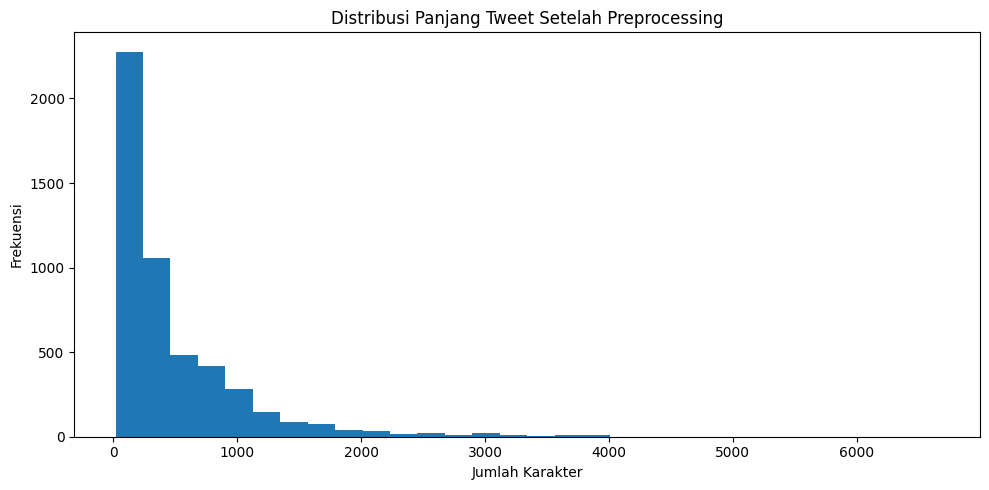

In [37]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.hist(df_raw[PREPROCESS_COL].str.len(), bins=30)

plt.title("Distribusi Panjang Tweet Setelah Preprocessing")
plt.xlabel("Jumlah Karakter")
plt.ylabel("Frekuensi")

plt.tight_layout()

plt.savefig(
    OUTPUT + "/Gambar_4_2_PanjangTweet.png",
    dpi=300
)

plt.show()

In [39]:
import re

cek_http = df_raw[PREPROCESS_COL].str.contains(r"http|https", case=False, na=False).sum()
cek_mention = df_raw[PREPROCESS_COL].str.contains(r"@", na=False).sum()
cek_hashtag = df_raw[PREPROCESS_COL].str.contains(r"#", na=False).sum()

print("="*50)
print("HASIL AUDIT PREPROCESSING")
print("="*50)
print(f"URL tersisa      : {cek_http}")
print(f"Mention tersisa  : {cek_mention}")
print(f"Hashtag tersisa  : {cek_hashtag}")

HASIL AUDIT PREPROCESSING
URL tersisa      : 0
Mention tersisa  : 0
Hashtag tersisa  : 0


In [44]:
# ==========================
# Statistik Hasil Preprocessing
# ==========================

stat_pre = pd.DataFrame({
    "Parameter":[
        "Jumlah Tweet",
        "Tweet Kosong",
        "Tweet Unik",
        "Rata-rata Panjang Tweet",
        "Tweet Terpanjang",
        "Tweet Terpendek"
    ],

    "Nilai":[
        len(df_raw),
        (df_raw["text_preprocessed"]=="").sum(),
        df_raw["text_preprocessed"].nunique(),
        round(df_raw["text_preprocessed"].str.len().mean(),2),
        df_raw["text_preprocessed"].str.len().max(),
        df_raw["text_preprocessed"].str.len().min()
    ]
})

display(stat_pre)

stat_pre.to_excel(
    OUTPUT+"/Tabel_4_4_Statistik_Preprocessing.xlsx",
    index=False
)

,Parameter,Nilai
0,Jumlah Tweet,5000.00
1,Tweet Kosong,0.00
2,Tweet Unik,4972.00
3,Rata-rata Panjang Tweet,289.72
4,Tweet Terpanjang,3860.00
5,Tweet Terpendek,5.00


In [46]:
contoh = df_raw[[
    "text",
    "text_clean",
    "text_preprocessed"
]].head(20)

display(contoh)

contoh.to_excel(
    OUTPUT+"/Tabel_4_5_Contoh_Preprocessing.xlsx",
    index=False
)

,text,text_clean,text_preprocessed
0,Anggota Komisi III DPR RI dari Fraksi PDI-P Sa...,anggota komisi iii dpr ri dari fraksi pdi p sa...,anggota komisi iii fraksi pdi safaruddin cecar...
1,Komisi III DPR RI mengingatkan majelis hakim P...,komisi iii dpr ri mengingatkan majelis hakim p...,komisi iii majelis hakim adil negeri batam jad...
2,"Mulan DPR Lulusan SMA? Tunggu, Cek Dulu Pendid...",mulan dpr lulusan sma tunggu cek dulu pendidik...,mulan lulus tunggu cek didik tum parpol jagat ...
3,Benarkah revisi UUP2SK membuat exchange lokal ...,benarkah revisi uup sk membuat exchange lokal ...,revisi uup suka exchange lokal kompetitif picu...
4,"Ketua DPR RI, Puan Maharani, menghadiri forum ...",ketua dpr ri puan maharani menghadiri forum mi...,ketua puan maharani hadir forum mikta speakers...
5,Badan Legislasi (Baleg) DPR RI mengadakan Rapa...,badan legislasi baleg dpr ri mengadakan rapat ...,badan legislasi baleg ada rapat kemendikdasmen...
6,Komisi III DPR RI akan menggelar sidang pengam...,komisi iii dpr ri akan menggelar sidang pengam...,komisi iii gelar sidang ambil putus tingkat ru...
7,Wakil Ketua Komisi XII DPR RI Sugeng Suparwoto...,wakil ketua komisi xii dpr ri sugeng suparwoto...,wakil ketua komisi xii sugeng suparwoto dorong...
8,DPR RI bersama pemerintah memastikan layanan k...,dpr ri bersama pemerintah memastikan layanan k...,perintah layan sehat serta bpjs sehat terima b...
9,KOMISI XI DPR RI resmi menetapkan Wakil Menter...,komisi xi dpr ri resmi menetapkan wakil menter...,komisi xi resmi tetap wakil menteri uang thoma...


In [48]:
ringkasan = pd.DataFrame({

    "Tahap":[
        "Original",
        "Cleaning",
        "Preprocessing"
    ],

    "Rata-rata Karakter":[
        df_raw["text"].str.len().mean(),
        df_raw["text_clean"].str.len().mean(),
        df_raw["text_preprocessed"].str.len().mean()
    ],

    "Rata-rata Kata":[
        df_raw["text"].str.split().str.len().mean(),
        df_raw["text_clean"].str.split().str.len().mean(),
        df_raw["text_preprocessed"].str.split().str.len().mean()
    ]

})

display(ringkasan)

ringkasan.to_excel(
    OUTPUT+"/Tabel_4_6_Ringkasan_Preprocessing.xlsx",
    index=False
)

,Tahap,Rata-rata Karakter,Rata-rata Kata
0,Original,567.7514,74.8298
1,Cleaning,500.9368,71.0434
2,Preprocessing,289.7162,43.0174


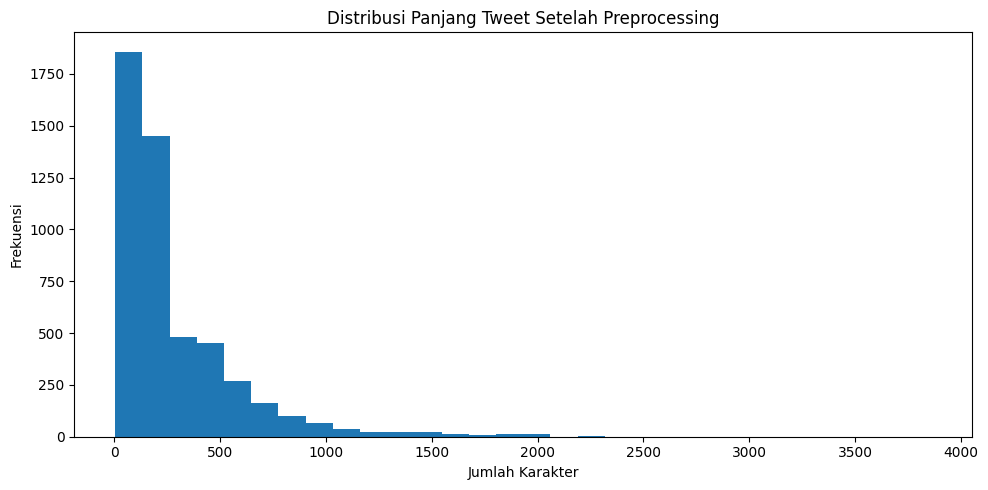

In [50]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.hist(
    df_raw["text_preprocessed"].str.len(),
    bins=30
)

plt.title("Distribusi Panjang Tweet Setelah Preprocessing")

plt.xlabel("Jumlah Karakter")

plt.ylabel("Frekuensi")

plt.tight_layout()

plt.savefig(
    OUTPUT+"/Gambar_4_2_Histogram_Preprocessing.png",
    dpi=300
)

plt.show()

In [52]:
import re

cek_url = df_raw["text_preprocessed"].str.contains(
    r"http|https",
    case=False,
    na=False
).sum()

cek_mention = df_raw["text_preprocessed"].str.contains(
    "@",
    na=False
).sum()

cek_hashtag = df_raw["text_preprocessed"].str.contains(
    "#",
    na=False
).sum()

print("="*50)
print("AUDIT PREPROCESSING")
print("="*50)

print("URL tersisa      :", cek_url)
print("Mention tersisa  :", cek_mention)
print("Hashtag tersisa  :", cek_hashtag)

AUDIT PREPROCESSING
URL tersisa      : 0
Mention tersisa  : 0
Hashtag tersisa  : 0


In [55]:
from collections import Counter

kata = " ".join(df_raw["text_preprocessed"]).split()

top20 = Counter(kata).most_common(20)

top20 = pd.DataFrame(
    top20,
    columns=["Kata","Frekuensi"]
)

display(top20)

top20.to_excel(
    OUTPUT+"/Tabel_4_7_Top20_Kata.xlsx",
    index=False
)

,Kata,Frekuensi
0,komisi,3243
1,anggota,2050
2,ketua,1957
3,perintah,1553
4,negara,1244
5,undang,1243
6,hukum,1139
7,presiden,1086
8,rapat,1083
9,menteri,1076


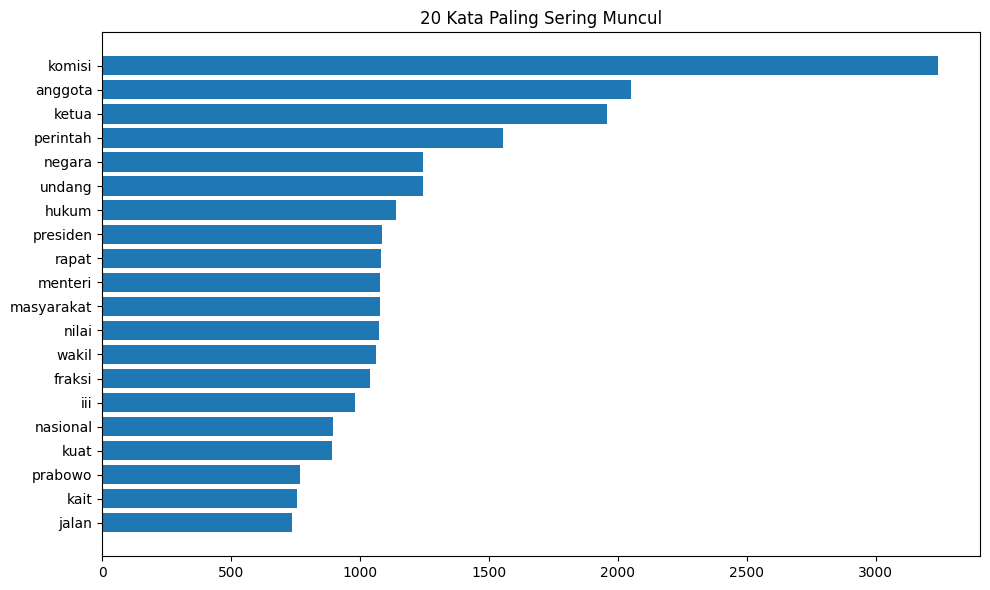

In [56]:
plt.figure(figsize=(10,6))

plt.barh(
    top20["Kata"],
    top20["Frekuensi"]
)

plt.title("20 Kata Paling Sering Muncul")

plt.gca().invert_yaxis()

plt.tight_layout()

plt.savefig(
    OUTPUT+"/Gambar_4_3_Top20Kata.png",
    dpi=300
)

plt.show()

In [57]:
# ┌─────────────────────────────────────────────────────────────────────────┐
# │ CELL 7  ─  NB-4: LABELING DENGAN LEXICON InSet                          │
# │  (Persis seperti notebook 4 referensi lailikanabila)                    │
# │  Metode: load InSet ke SentimentIntensityAnalyzer (VADER custom)        │
# │          hitung compound score → label positif/negatif/netral           │
# └─────────────────────────────────────────────────────────────────────────┘
# %%

print("=" * 65)
print("  NB-4 : LABELING — LEXICON InSet")
print("=" * 65)

# ── Load InSet ke dalam dua SentimentIntensityAnalyzer (persis referensi) ─
# Referensi lailikanabila notebook 4:
#   sia1A = InSet negatif, sia1B = InSet positif
#   compound = sia1A.polarity_scores(text)["compound"]
#            + sia1B.polarity_scores(text)["compound"]
#   label: compound > 0 → positif, compound < 0 → negatif, else → netral

def load_inset_to_sia(pos_lexicon_path: str, neg_lexicon_path: str):
    """
    Muat InSet lexicon dari file positif dan negatif terpisah (misal: .tsv).
    Asumsi format file: kata\tbobot
    """
    pos_lex, neg_lex = {}, {}

    # Load positive lexicon from TSV
    try:
        # Assuming TSV files have no header and two columns: 'kata' and 'bobot'
        pos_df = pd.read_csv(pos_lexicon_path, sep='\t', header=None, names=['kata', 'bobot'])
        pos_lex = dict(zip(
            pos_df['kata'].astype(str).str.lower(),
            pd.to_numeric(pos_df['bobot'], errors="coerce").fillna(0).abs()
        ))
    except Exception as e:
        print(f"Error loading positive lexicon from {pos_lexicon_path}: {e}")

    # Load negative lexicon from TSV
    try:
        # Assuming TSV files have no header and two columns: 'kata' and 'bobot'
        neg_df = pd.read_csv(neg_lexicon_path, sep='\t', header=None, names=['kata', 'bobot'])
        neg_lex = dict(zip(
            neg_df['kata'].astype(str).str.lower(),
            pd.to_numeric(neg_df['bobot'], errors="coerce").fillna(0).abs()
        ))
    except Exception as e:
        print(f"Error loading negative lexicon from {neg_lexicon_path}: {e}")

    # Masukkan ke VADER SentimentIntensityAnalyzer
    sia_neg = SentimentIntensityAnalyzer()
    sia_pos = SentimentIntensityAnalyzer()
    sia_neg.lexicon.update({k: -v for k, v in neg_lex.items()})
    sia_pos.lexicon.update({k:  v for k, v in pos_lex.items()})

    print(f"   InSet positif: {len(pos_lex):,} kata | InSet negatif: {len(neg_lex):,} kata")
    return sia_neg, sia_pos

sia_neg, sia_pos = load_inset_to_sia(POS_PATH, NEG_PATH)

def label_inset(text: str,
                sia_neg: SentimentIntensityAnalyzer,
                sia_pos: SentimentIntensityAnalyzer,
                threshold: float = 0.0) -> str:
    """
    Persis logika notebook 4 lailikanabila:
    compound = compound(sia_neg) + compound(sia_pos)
    > threshold  → positif
    < -threshold → negatif
    else         → netral
    """
    compound = (sia_neg.polarity_scores(text)["compound"] +
                sia_pos.polarity_scores(text)["compound"])
    if   compound > threshold : return "positif"
    elif compound < -threshold: return "negatif"
    else                      : return "netral"

df_raw["sentimen"] = df_raw["text_preprocessed"].apply(
    lambda x: label_inset(x, sia_neg, sia_pos)
)

dist = df_raw["sentimen"].value_counts()
print(f"\n📊 Distribusi hasil labeling InSet:")
for kls, cnt in dist.items():
    pct = cnt / len(df_raw) * 100
    print(f"   {kls.capitalize():<10}: {cnt:>6,}  ({pct:.2f}%)")

# ── Simpan data berlabel ──────────────────────────────────────────────────
df_raw.to_excel(f"{OUTPUT_DIR}/nb4_data_berlabel.xlsx", index=False)
print(f"\n💾 Data berlabel disimpan → nb4_data_berlabel.xlsx")

  NB-4 : LABELING — LEXICON InSet
   InSet positif: 3,608 kata | InSet negatif: 6,607 kata

📊 Distribusi hasil labeling InSet:
   Negatif   :  2,568  (51.36%)
   Positif   :  2,141  (42.82%)
   Netral    :    291  (5.82%)

💾 Data berlabel disimpan → nb4_data_berlabel.xlsx


In [60]:
# ==========================================
# Distribusi Sentimen
# ==========================================

sentiment_count = (
    df_raw["sentimen"]
    .value_counts()
    .reset_index()
)

sentiment_count.columns = ["Sentimen", "Jumlah"]

sentiment_count["Persentase (%)"] = (
    sentiment_count["Jumlah"] /
    sentiment_count["Jumlah"].sum() * 100
).round(2)

display(sentiment_count)

sentiment_count.to_excel(
    OUTPUT+"/Tabel_4_8_Distribusi_Sentimen.xlsx",
    index=False
)

,Sentimen,Jumlah,Persentase (%)
0,negatif,2568,51.36
1,positif,2141,42.82
2,netral,291,5.82


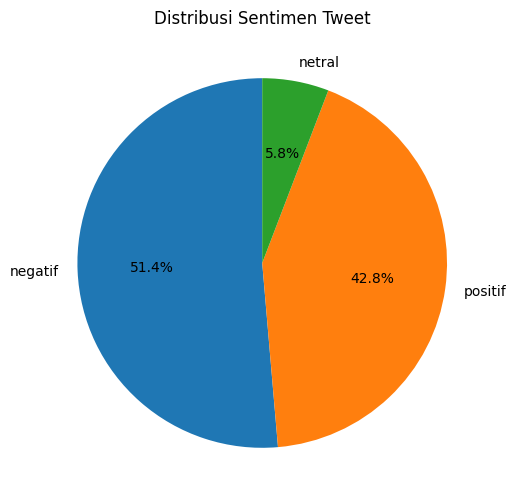

In [61]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))

plt.pie(
    sentiment_count["Jumlah"],
    labels=sentiment_count["Sentimen"],
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Distribusi Sentimen Tweet")

plt.savefig(
    OUTPUT+"/Gambar_4_4_PieSentimen.png",
    dpi=300
)

plt.show()

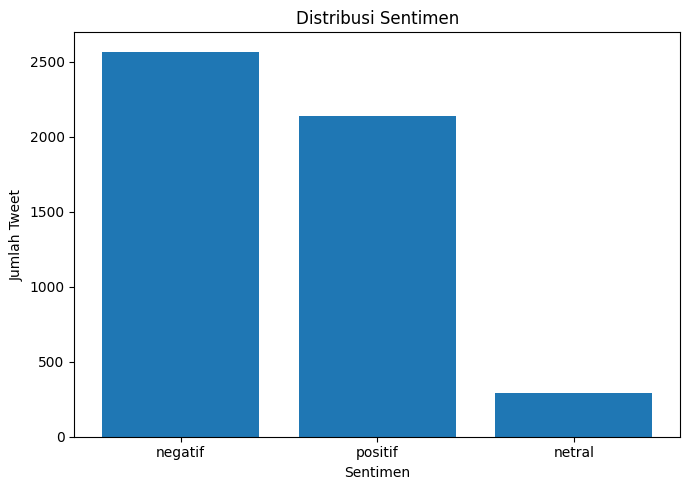

In [62]:
plt.figure(figsize=(7,5))

plt.bar(
    sentiment_count["Sentimen"],
    sentiment_count["Jumlah"]
)

plt.title("Distribusi Sentimen")

plt.xlabel("Sentimen")

plt.ylabel("Jumlah Tweet")

plt.tight_layout()

plt.savefig(
    OUTPUT+"/Gambar_4_5_BarSentimen.png",
    dpi=300
)

plt.show()

In [64]:
positif = (
    df_raw[df_raw["sentimen"]=="positif"]
    [["text_preprocessed","sentimen"]]
    .head(10)
)

negatif = (
    df_raw[df_raw["sentimen"]=="negatif"]
    [["text_preprocessed","sentimen"]]
    .head(10)
)

netral = (
    df_raw[df_raw["sentimen"]=="netral"]
    [["text_preprocessed","sentimen"]]
    .head(10)
)

contoh_sentimen = pd.concat([
    positif,
    negatif,
    netral
])

display(contoh_sentimen)

contoh_sentimen.to_excel(
    OUTPUT+"/Tabel_4_9_Contoh_Sentimen.xlsx",
    index=False
)

,text_preprocessed,sentimen
7,wakil ketua komisi xii sugeng suparwoto dorong...,positif
8,perintah layan sehat serta bpjs sehat terima b...,positif
9,komisi xi resmi tetap wakil menteri uang thoma...,positif
10,kasihan banget lu harap kompak terima lu trm l...,positif
11,rapat komisi vii senin menteri pariwisata widi...,positif
13,fraksi partai adil sejahtera pks raih juara ii...,positif
16,bahas revisi uu kembang kuat sektor uang suka ...,positif
18,badan legislasi baleg resmi pakat cantum nota ...,positif
19,anggota fraksi gerindra azis subekti sambut re...,positif
21,momen ketua hadir acara buka puasa selenggara ...,positif


In [66]:
timeline = (
    df_raw.groupby(["year_month","sentimen"])
      .size()
      .unstack(fill_value=0)
)

display(timeline)

timeline.to_excel(
    OUTPUT+"/Tabel_4_10_TimelineSentimen.xlsx"
)

sentimen,negatif,netral,positif
year_month,,,
2025-11,348,42,327
2025-12,367,40,219
2026-01,356,38,287
2026-02,316,42,262
2026-03,239,19,248
2026-04,337,27,277
2026-05,346,44,260
2026-06,259,39,261


<Figure size 1200x500 with 0 Axes>

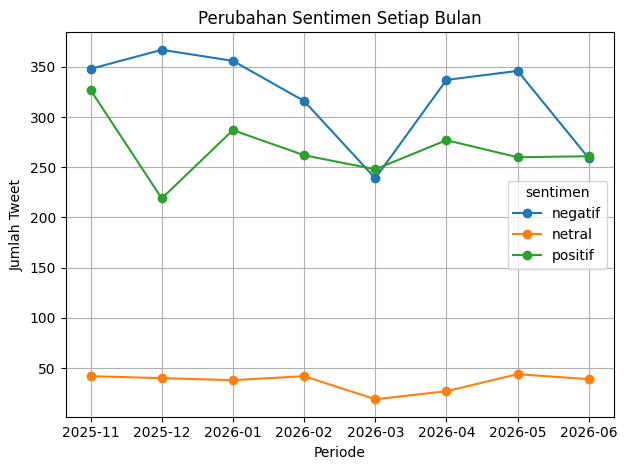

In [67]:
plt.figure(figsize=(12,5))

timeline.plot(marker="o")

plt.title("Perubahan Sentimen Setiap Bulan")

plt.xlabel("Periode")

plt.ylabel("Jumlah Tweet")

plt.grid(True)

plt.tight_layout()

plt.savefig(
    OUTPUT+"/Gambar_4_6_TimelineSentimen.png",
    dpi=300
)

plt.show()

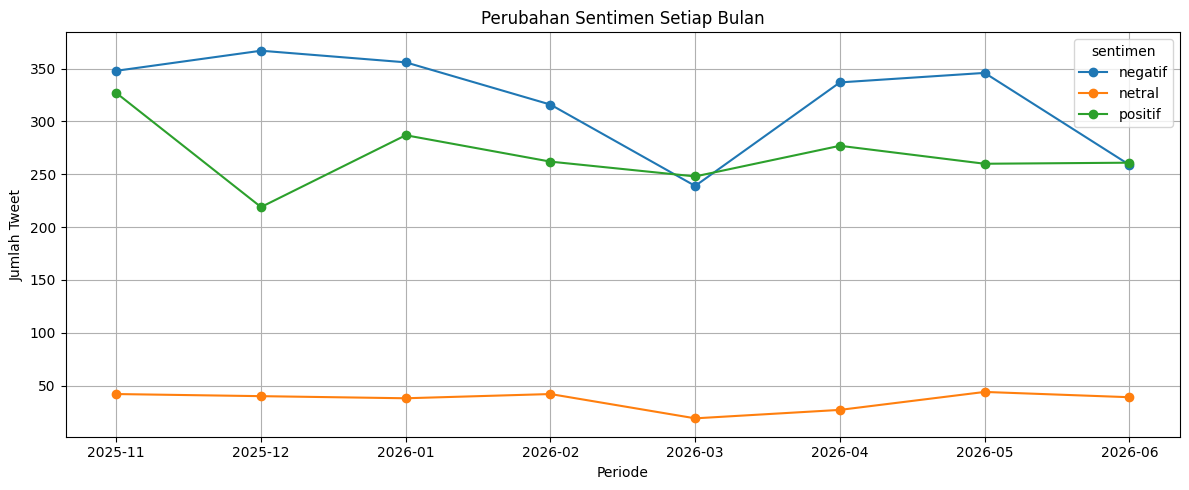

In [68]:
ax = timeline.plot(figsize=(12,5), marker="o")
ax.set_title("Perubahan Sentimen Setiap Bulan")
ax.set_xlabel("Periode")
ax.set_ylabel("Jumlah Tweet")
ax.grid(True)
plt.tight_layout()
plt.savefig(OUTPUT+"/Gambar_4_6_TimelineSentimen.png", dpi=300)
plt.show()

In [69]:
print("="*60)
print("RINGKASAN SENTIMEN")
print("="*60)

for i,row in sentiment_count.iterrows():
    print(
        f"{row['Sentimen']:10s} : "
        f"{row['Jumlah']:5d} tweet "
        f"({row['Persentase (%)']}%)"
    )

RINGKASAN SENTIMEN
negatif    :  2568 tweet (51.36%)
positif    :  2141 tweet (42.82%)
netral     :   291 tweet (5.82%)


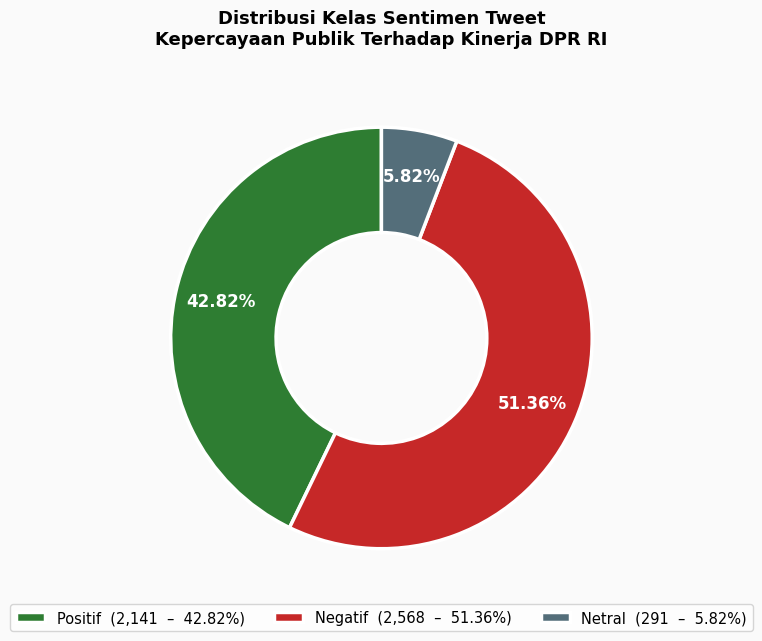

✅ Viz 1: Donut distribusi tersimpan.


In [58]:
# ┌─────────────────────────────────────────────────────────────────────────┐
# │ CELL 8  ─  VISUALISASI 1: DONUT CHART DISTRIBUSI SENTIMEN               │
# └─────────────────────────────────────────────────────────────────────────┘
# %%

klabel_order = ["positif","negatif","netral"]
klabel_exist = [k for k in klabel_order if k in dist.index]
values_d     = [dist[k] for k in klabel_exist]
colors_d     = [PAL[k]  for k in klabel_exist]

fig, ax = plt.subplots(figsize=(7.5, 6.5), facecolor=PAL["bg"])
wedges, _, autotexts = ax.pie(
    values_d, autopct="%1.2f%%", startangle=90,
    colors=colors_d, pctdistance=0.78,
    wedgeprops=dict(width=0.50, edgecolor="white", linewidth=2.5)
)
for at in autotexts:
    at.set(fontsize=12, fontweight="bold", color="white")

legend_labels = [f"{k.capitalize()}  ({v:,}  –  {v/len(df_raw)*100:.2f}%)"
                 for k, v in zip(klabel_exist, values_d)]
ax.legend(wedges, legend_labels,
          loc="lower center", bbox_to_anchor=(0.5, -0.07),
          ncol=len(klabel_exist), fontsize=10.5)
ax.set_title("Distribusi Kelas Sentimen Tweet\nKepercayaan Publik Terhadap Kinerja DPR RI",
             fontsize=13, fontweight="bold", pad=22)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/viz1_donut_distribusi.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Viz 1: Donut distribusi tersimpan.")

In [ ]:
# ┌─────────────────────────────────────────────────────────────────────────┐
# │ CELL 9  ─  VISUALISASI 2: 10 SAMPEL TWEET BERLABEL                      │
# └─────────────────────────────────────────────────────────────────────────┘
# %%

n_each  = max(1, 10 // len(klabel_exist))
samples = (df_raw.groupby("sentimen", group_keys=False)
           .apply(lambda x: x.sample(min(n_each, len(x)), random_state=42)))
tabel_sample = (samples[[TEXT_COL,"text_preprocessed","sentimen"]]
                .head(10).reset_index(drop=True))
tabel_sample.columns = ["Tweet Asli","Tweet Preprocessed","Sentimen"]
tabel_sample.index  += 1

BG_ROW = {"positif":"#C8E6C9","negatif":"#FFCDD2","netral":"#CFD8DC"}
def row_color(row):
    c = BG_ROW.get(row["Sentimen"],"#FFFFFF")
    return [f"background-color:{c}"]*len(row)

print("📋 10 SAMPEL TWEET BESERTA KATEGORI SENTIMEN")
display(
    tabel_sample.style.apply(row_color, axis=1)
    .set_table_styles([
        {"selector":"th","props":[("background",PAL["primary"]),("color","white")]},
    ])
)
tabel_sample.to_excel(f"{OUTPUT_DIR}/tabel_sampel_tweet.xlsx")
print("✅ Tabel sampel tersimpan.")

In [ ]:
# ┌─────────────────────────────────────────────────────────────────────────┐
# │ CELL 10 ─  VISUALISASI 3: TREN SENTIMEN BERDASARKAN WAKTU               │
# └─────────────────────────────────────────────────────────────────────────┘
# %%

if DATE_COL and DATE_COL in df_raw.columns:
    df_raw[DATE_COL] = pd.to_datetime(df_raw[DATE_COL], errors="coerce")
    df_t = df_raw.dropna(subset=[DATE_COL]).copy()
    df_t["periode"] = df_t[DATE_COL].dt.to_period("M")
    trend = (df_t.groupby(["periode","sentimen"])
             .size().unstack(fill_value=0).reset_index())
    trend["periode"] = trend["periode"].astype(str)

    fig, ax = plt.subplots(figsize=(13, 5), facecolor=PAL["bg"])
    for kls in klabel_exist:
        if kls in trend.columns:
            ax.plot(trend["periode"], trend[kls], marker="o",
                    color=PAL[kls], linewidth=2.5, markersize=7,
                    label=kls.capitalize())
    for kls in ["positif","negatif"]:
        if kls in trend.columns:
            ax.fill_between(trend["periode"], trend[kls],
                            alpha=0.08, color=PAL[kls])
    ax.set_title("Tren Sentimen Publik Terhadap Kinerja DPR RI per Bulan\n"
                 "(Periode Agustus – Desember 2025)",
                 fontsize=13, fontweight="bold")
    ax.set_xlabel("Bulan"); ax.set_ylabel("Jumlah Tweet")
    ax.legend(fontsize=11); ax.grid(True, alpha=0.3, linestyle="--")
    plt.xticks(rotation=45, ha="right"); plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/viz3_tren_waktu.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("✅ Viz 3: Line chart tren waktu tersimpan.")
else:
    print("⚠️  Kolom tanggal tidak ditemukan — Viz 3 dilewati.")

In [ ]:
# ┌─────────────────────────────────────────────────────────────────────────┐
# │ CELL 11 ─  VISUALISASI 4 & 5: WORDCLOUD + TOP-10 KATA                   │
# └─────────────────────────────────────────────────────────────────────────┘
# %%

WARNA_WC = {"positif":"Greens","negatif":"Reds","netral":"Blues"}

# ── WordCloud ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, len(klabel_exist),
                          figsize=(6*len(klabel_exist), 5), facecolor=PAL["bg"])
if len(klabel_exist) == 1: axes = [axes]
fig.suptitle("WordCloud per Kelas Sentimen — Kepercayaan Publik Terhadap DPR RI",
             fontsize=14, fontweight="bold", y=1.02)

for ax, kls in zip(axes, klabel_exist):
    corpus = " ".join(df_raw[df_raw["sentimen"]==kls]["text_preprocessed"])
    if not corpus.strip():
        ax.axis("off"); ax.set_title(kls.capitalize()); continue
    wc = WordCloud(width=600, height=400, background_color="white",
                   colormap=WARNA_WC[kls], max_words=120,
                   collocations=False).generate(corpus)
    ax.imshow(wc, interpolation="bilinear"); ax.axis("off")
    ax.set_title(kls.capitalize(), fontsize=14, fontweight="bold",
                 color=PAL[kls], pad=10)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/viz4_wordcloud.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Viz 4: WordCloud tersimpan.")

# ── Bar Chart Top-10 Kata ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, len(klabel_exist),
                          figsize=(7*len(klabel_exist), 6), facecolor=PAL["bg"])
if len(klabel_exist) == 1: axes = [axes]
fig.suptitle("Top 10 Kata Terbanyak per Kelas Sentimen (Term Frequency)",
             fontsize=13, fontweight="bold", y=1.02)

for ax, kls in zip(axes, klabel_exist):
    corpus = " ".join(df_raw[df_raw["sentimen"]==kls]["text_preprocessed"])
    freq   = Counter(corpus.split()).most_common(10)
    if not freq: ax.axis("off"); continue
    words, counts = zip(*freq)
    bars = ax.barh(list(words[::-1]), list(counts[::-1]),
                   color=PAL[kls], edgecolor="white", height=0.65, alpha=0.9)
    for bar, cnt in zip(bars, counts[::-1]):
        ax.text(bar.get_width() + max(counts)*0.015,
                bar.get_y() + bar.get_height()/2,
                f"{cnt:,}", va="center", fontsize=9, fontweight="bold")
    ax.set_title(kls.capitalize(), fontsize=12, fontweight="bold", color=PAL[kls])
    ax.set_xlabel("Frekuensi")
    ax.set_xlim(0, max(counts)*1.22)
    ax.spines[["top","right"]].set_visible(False)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/viz5_top10_kata.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Viz 5: Bar chart term frequency tersimpan.")

In [70]:
# ┌─────────────────────────────────────────────────────────────────────────┐
# │ CELL 12 ─  TABEL TF-IDF (TF, IDF, TF-IDF)                              │
# │  Sesuai proposal §6.4: W_ij = tf_ij × log(N/df_i)                      │
# └─────────────────────────────────────────────────────────────────────────┘
# %%

print("=" * 65)
print("  TABEL 8: PERHITUNGAN TF-IDF (5 dokumen sampel, 15 kata)")
print("=" * 65)

SAMPLE_DOCS = df_raw["text_preprocessed"].dropna().head(5).tolist()
N_DOCS      = len(SAMPLE_DOCS)

def tf_val(word, doc):
    tokens = doc.split()
    return tokens.count(word) / len(tokens) if tokens else 0

def idf_smooth(word, docs):
    """Smooth IDF (sklearn): log((1+N)/(1+df)) + 1"""
    df_cnt = sum(1 for d in docs if word in d.split())
    return math.log((1 + N_DOCS) / (1 + df_cnt)) + 1

vocab_sample = [w for w,_ in Counter(" ".join(SAMPLE_DOCS).split()).most_common(15)]

rows_tfidf = []
for i, doc in enumerate(SAMPLE_DOCS, 1):
    for w in vocab_sample:
        tf  = round(tf_val(w, doc), 5)
        idf = round(idf_smooth(w, SAMPLE_DOCS), 5)
        tfidf_v = round(tf * idf, 5)
        if tf > 0:
            rows_tfidf.append({
                "Dokumen":f"D{i}", "Kata":w,
                "TF":tf, "IDF":idf, "TF-IDF":tfidf_v
            })

df_tfidf = pd.DataFrame(rows_tfidf).sort_values(
    ["Dokumen","TF-IDF"], ascending=[True,False]
).reset_index(drop=True)

display(
    df_tfidf.style
    .background_gradient(subset=["TF-IDF"], cmap="Blues")
    .format({"TF":"{:.5f}","IDF":"{:.5f}","TF-IDF":"{:.5f}"})
    .set_table_styles([
        {"selector":"th","props":[("background",PAL["primary"]),("color","white")]},
        {"selector":"tr:nth-child(even)","props":[("background","#EEF2FF")]},
    ])
    .hide(axis="index")
)
df_tfidf.to_excel(f"{OUTPUT_DIR}/tabel_tfidf_perhitungan.xlsx", index=False)
print("✅ Tabel TF-IDF tersimpan.")

  TABEL 8: PERHITUNGAN TF-IDF (5 dokumen sampel, 15 kata)


Dokumen,Kata,TF,IDF,TF-IDF
D1,anggota,0.03571,1.69315,0.06046
D1,komisi,0.03571,1.40547,0.05019
D2,komisi,0.03571,1.40547,0.05019
D3,mulan,0.03636,2.09861,0.07631
D3,didik,0.03030,2.09861,0.06359
D3,jameela,0.02424,2.09861,0.05087
D3,megawati,0.02424,2.09861,0.05087
D3,anggota,0.02424,1.69315,0.04104
D3,lulus,0.01818,2.09861,0.03815
D3,ramai,0.01818,2.09861,0.03815


✅ Tabel TF-IDF tersimpan.


In [75]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

# Initialize TF-IDF Vectorizer as done in NB-5 quick version
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    sublinear_tf=True
)

# Transform the entire preprocessed text data (X_all from df_model) into TF-IDF features
X_tfidf = tfidf.fit_transform(X_all)

X = X_tfidf
y = y_all # Use y_all which is defined from df_model["sentimen"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("="*60)
print("PEMBAGIAN DATA")
print("="*60)
print("Training :", len(y_train))
print("Testing  :", len(y_test))

PEMBAGIAN DATA
Training : 4000
Testing  : 1000


In [77]:
train_dist = pd.Series(y_train).value_counts().sort_index()
test_dist = pd.Series(y_test).value_counts().sort_index()

split_df = pd.DataFrame({
    "Training": train_dist,
    "Testing": test_dist
}).fillna(0).astype(int)

display(split_df)

,Training,Testing
negatif,2054,514
netral,233,58
positif,1713,428


In [81]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC

param_grid = {
    "C":[0.1,1,5,10,20]
}

grid = GridSearchCV(
    estimator=SVC(kernel="rbf"),
    param_grid=param_grid,
    cv=5,
    scoring="f1_weighted",
    n_jobs=-1
)

grid.fit(X_train,y_train)

print("Best Parameter :",grid.best_params_)
print("Best Score     :",grid.best_score_)

Best Parameter : {'C': 10}
Best Score     : 0.752978264030111


In [82]:
best_model = grid.best_estimator_

best_model.fit(X_train,y_train)

y_pred = best_model.predict(X_test)

In [83]:
from sklearn.metrics import classification_report

report = classification_report(
    y_test,
    y_pred,
    digits=4,
    output_dict=True
)

report_df = pd.DataFrame(report).transpose()

display(report_df)

report_df.to_excel(
    OUTPUT+"/Classification_Report.xlsx"
)

,precision,recall,f1-score,support
negatif,0.784314,0.856031,0.818605,514.000
netral,0.166667,0.017241,0.031250,58.000
positif,0.778291,0.787383,0.782811,428.000
accuracy,0.778000,0.778000,0.778000,0.778
macro avg,0.576424,0.553552,0.544222,1000.000
weighted avg,0.745912,0.778000,0.757618,1000.000


📊 Membuat ilustrasi visual K-Fold ...


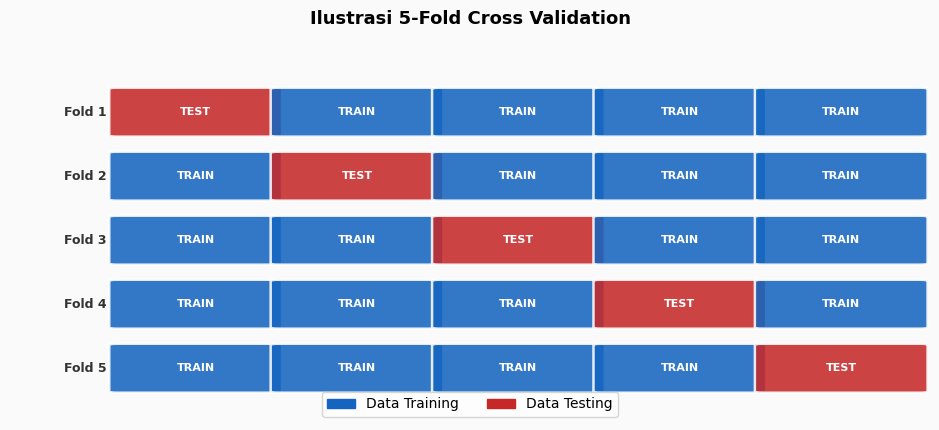

   ✅ Ilustrasi K-Fold k=5 tersimpan.


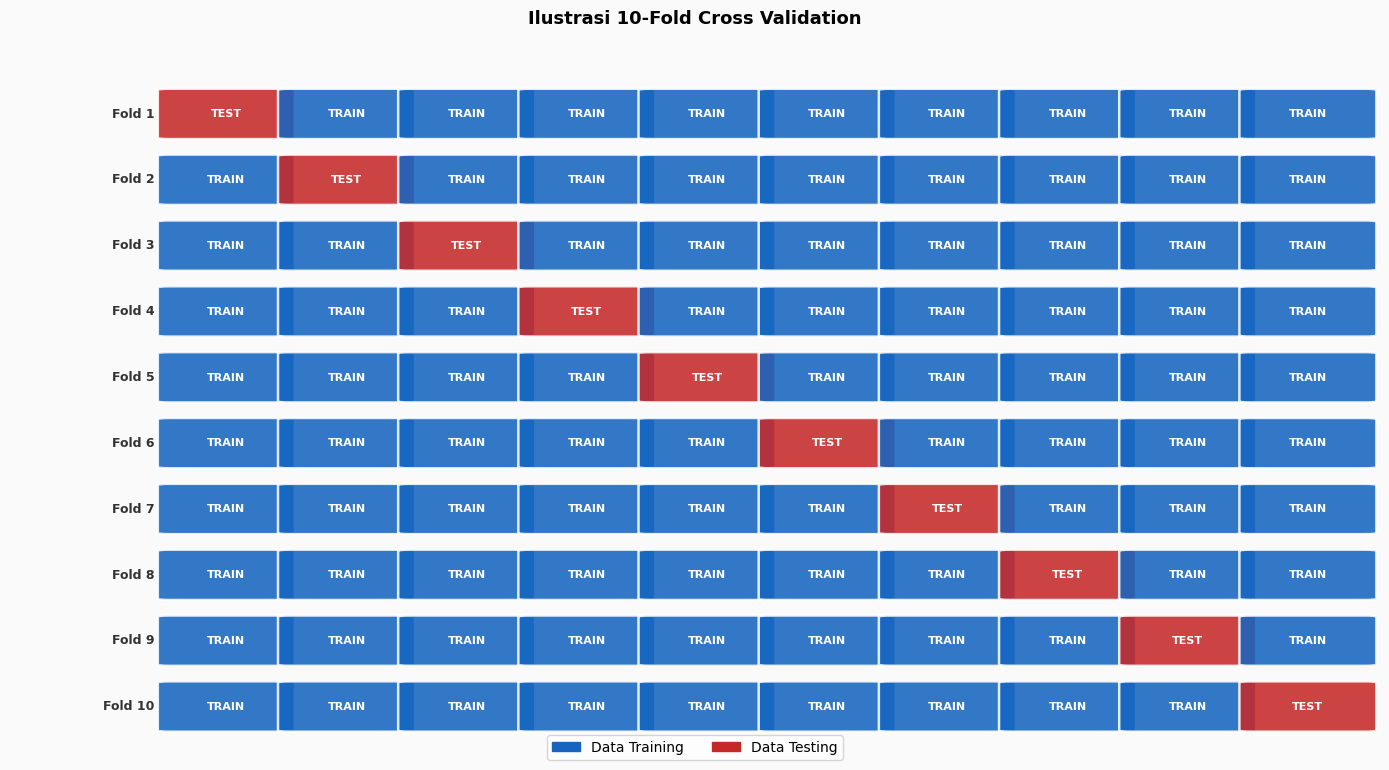

   ✅ Ilustrasi K-Fold k=10 tersimpan.


In [71]:
# ┌─────────────────────────────────────────────────────────────────────────┐
# │ CELL 13 ─  ILUSTRASI VISUAL K-FOLD                                      │
# └─────────────────────────────────────────────────────────────────────────┘
# %%

def plot_kfold_ilustrasi(k: int):
    cell_h, gap_h = 0.50, 0.18
    cell_w = 1.0 / k
    fig_h  = k * (cell_h + gap_h) + 1.0
    fig, ax = plt.subplots(figsize=(min(14, k*1.5+2), fig_h), facecolor=PAL["bg"])
    ax.set_facecolor(PAL["bg"])

    for fold in range(k):
        y = (k - fold - 1) * (cell_h + gap_h) + 0.3
        ax.text(-0.01, y + cell_h/2, f"Fold {fold+1}",
                ha="right", va="center", fontsize=9,
                fontweight="bold", color="#333333")
        for col in range(k):
            is_test = (col == fold)
            color   = PAL["negatif"] if is_test else PAL["primary"]
            rect = mpatches.FancyBboxPatch(
                (col*cell_w + 0.003, y), cell_w - 0.006, cell_h,
                boxstyle="round,pad=0.01", facecolor=color,
                edgecolor="white", linewidth=1.8, alpha=0.87
            )
            ax.add_patch(rect)
            ax.text(col*cell_w + cell_w/2, y + cell_h/2,
                    "TEST" if is_test else "TRAIN",
                    ha="center", va="center",
                    fontsize=8, fontweight="bold", color="white")

    ax.set_xlim(-0.13, 1.01)
    ax.set_ylim(0, k*(cell_h+gap_h)+0.6)
    ax.axis("off")
    ax.set_title(f"Ilustrasi {k}-Fold Cross Validation",
                 fontsize=13, fontweight="bold", pad=14)
    leg = [mpatches.Patch(color=PAL["primary"], label="Data Training"),
           mpatches.Patch(color=PAL["negatif"], label="Data Testing")]
    ax.legend(handles=leg, loc="lower center",
              bbox_to_anchor=(0.5, -0.01), ncol=2, fontsize=10)
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/viz9a_kfold_k{k}.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"   ✅ Ilustrasi K-Fold k={k} tersimpan.")

print("📊 Membuat ilustrasi visual K-Fold ...")
for kv in [5, 10]:
    plot_kfold_ilustrasi(kv)

In [84]:
# =====================================================
# NB-5 FINAL
# CELL 1 : Persiapan Dataset
# =====================================================

import pandas as pd

df_model = df_raw.copy()

# Pastikan tidak ada data kosong
df_model = df_model.dropna(subset=["text_preprocessed", "sentimen"])

# Hilangkan tweet kosong
df_model = df_model[df_model["text_preprocessed"].str.strip() != ""]

df_model = df_model.reset_index(drop=True)

print("="*60)
print("DATASET MODEL")
print("="*60)

print("Jumlah data :", len(df_model))

print("\nDistribusi Sentimen")
print(df_model["sentimen"].value_counts())

display(df_model.head())

DATASET MODEL
Jumlah data : 5000

Distribusi Sentimen
sentimen
negatif    2568
positif    2141
netral      291
Name: count, dtype: int64


,id,text,createdAt,retweetCount,replyCount,likeCount,quoteCount,viewCount,bookmarkCount,lang,isReply,isQuote,year_month,word_count,char_count,text_clean,text_preprocessed,sentimen
0,2016677843728814512,Anggota Komisi III DPR RI dari Fraksi PDI-P Sa...,2026-01-29 01:00:40+00:00,22,13,81,2,6364,10,in,False,NaN,2026-01,40,282,anggota komisi iii dpr ri dari fraksi pdi p sa...,anggota komisi iii fraksi pdi safaruddin cecar...,negatif
1,2025821265161044402,Komisi III DPR RI mengingatkan majelis hakim P...,2026-02-23 06:33:22+00:00,0,0,4,0,939,0,in,False,NaN,2026-02,46,338,komisi iii dpr ri mengingatkan majelis hakim p...,komisi iii majelis hakim adil negeri batam jad...,negatif
2,2031081718581772370,"Mulan DPR Lulusan SMA? Tunggu, Cek Dulu Pendid...",2026-03-09 18:56:32+00:00,0,1,5,1,1775,0,in,False,NaN,2026-03,328,2395,mulan dpr lulusan sma tunggu cek dulu pendidik...,mulan lulus tunggu cek didik tum parpol jagat ...,negatif
3,2005895742150586624,Benarkah revisi UUP2SK membuat exchange lokal ...,2025-12-30 06:56:27+00:00,1,0,3,0,89,0,in,False,NaN,2025-12,28,234,benarkah revisi uup sk membuat exchange lokal ...,revisi uup suka exchange lokal kompetitif picu...,netral
4,1988814501538635897,"Ketua DPR RI, Puan Maharani, menghadiri forum ...",2025-11-13 03:41:42+00:00,0,8,16,0,194,0,in,False,NaN,2025-11,34,269,ketua dpr ri puan maharani menghadiri forum mi...,ketua puan maharani hadir forum mikta speakers...,negatif


In [85]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    df_model["text_preprocessed"],
    df_model["sentimen"],
    test_size=0.20,
    stratify=df_model["sentimen"],
    random_state=42
)

print("Train :", len(X_train))
print("Test  :", len(X_test))

Train : 4000
Test  : 1000


In [86]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=8000,
    ngram_range=(1,2),
    min_df=2,
    max_df=0.90,
    sublinear_tf=True,
    strip_accents="unicode"
)

X_train_vec = tfidf.fit_transform(X_train)

X_test_vec = tfidf.transform(X_test)

print(X_train_vec.shape)
print(X_test_vec.shape)

(4000, 8000)
(1000, 8000)


In [87]:
# ==========================================================
# CELL 4 : GridSearchCV (Optimized)
# ==========================================================

from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

param_grid = [

    {
        "kernel": ["linear"],
        "C": [0.01, 0.1, 0.5, 1, 2, 5, 10, 20],
        "class_weight": [None, "balanced"]
    },

    {
        "kernel": ["rbf"],
        "C": [1, 2, 5, 10],
        "gamma": ["scale", 0.01, 0.1],
        "class_weight": [None, "balanced"]
    }

]

grid = GridSearchCV(

    estimator=SVC(),

    param_grid=param_grid,

    scoring="f1_weighted",

    cv=5,

    n_jobs=-1,

    verbose=2

)

grid.fit(X_train_vec, y_train)

print("="*60)
print("GRID SEARCH SELESAI")
print("="*60)

print("Best Parameter")
print(grid.best_params_)

print()

print("Best CV Score")
print(round(grid.best_score_,4))

Fitting 5 folds for each of 40 candidates, totalling 200 fits
GRID SEARCH SELESAI
Best Parameter
{'C': 10, 'class_weight': 'balanced', 'gamma': 0.1, 'kernel': 'rbf'}

Best CV Score
0.762


In [88]:
# ==========================================================
# CELL 5 : Training Best Model
# ==========================================================

best_model = grid.best_estimator_

best_model.fit(X_train_vec, y_train)

y_pred = best_model.predict(X_test_vec)

print("Model selesai dilatih.")

Model selesai dilatih.


In [89]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

acc = accuracy_score(y_test,y_pred)

prec = precision_score(
    y_test,
    y_pred,
    average="weighted"
)

rec = recall_score(
    y_test,
    y_pred,
    average="weighted"
)

f1 = f1_score(
    y_test,
    y_pred,
    average="weighted"
)

hasil = pd.DataFrame({

"Metric":[
"Accuracy",
"Precision",
"Recall",
"F1 Score"
],

"Nilai":[
acc,
prec,
rec,
f1
]

})

hasil["Nilai"]=(hasil["Nilai"]*100).round(2)

display(hasil)

,Metric,Nilai
0,Accuracy,77.80
1,Precision,75.61
2,Recall,77.80
3,F1 Score,76.63


In [90]:
# =====================================================
# CELL 1 : Ringkasan Evaluasi Model
# =====================================================

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

hasil_model = pd.DataFrame({

    "Metric":[
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ],

    "Nilai":[
        accuracy_score(y_test,y_pred),
        precision_score(y_test,y_pred,average="weighted"),
        recall_score(y_test,y_pred,average="weighted"),
        f1_score(y_test,y_pred,average="weighted")
    ]

})

hasil_model["Nilai (%)"]=(hasil_model["Nilai"]*100).round(2)

display(hasil_model)

hasil_model.to_excel(
    OUTPUT_DIR+"/Tabel_Hasil_Model.xlsx",
    index=False
)

print("✅ Tabel hasil model berhasil disimpan.")

,Metric,Nilai,Nilai (%)
0,Accuracy,0.778000,77.80
1,Precision,0.756083,75.61
2,Recall,0.778000,77.80
3,F1 Score,0.766296,76.63


✅ Tabel hasil model berhasil disimpan.


In [91]:
from sklearn.metrics import classification_report

report = classification_report(
    y_test,
    y_pred,
    output_dict=True,
    digits=4
)

report_df = pd.DataFrame(report).transpose()

display(report_df)

report_df.to_excel(
    OUTPUT_DIR+"/Classification_Report.xlsx"
)

print("✅ Classification Report tersimpan.")

,precision,recall,f1-score,support
negatif,0.816602,0.822957,0.819767,514.000
netral,0.074074,0.034483,0.047059,58.000
positif,0.775824,0.824766,0.799547,428.000
accuracy,0.778000,0.778000,0.778000,0.778
macro avg,0.555500,0.560735,0.555458,1000.000
weighted avg,0.756083,0.778000,0.766296,1000.000


✅ Classification Report tersimpan.


,negatif,netral,positif
negatif,423,12,79
netral,33,2,23
positif,62,13,353


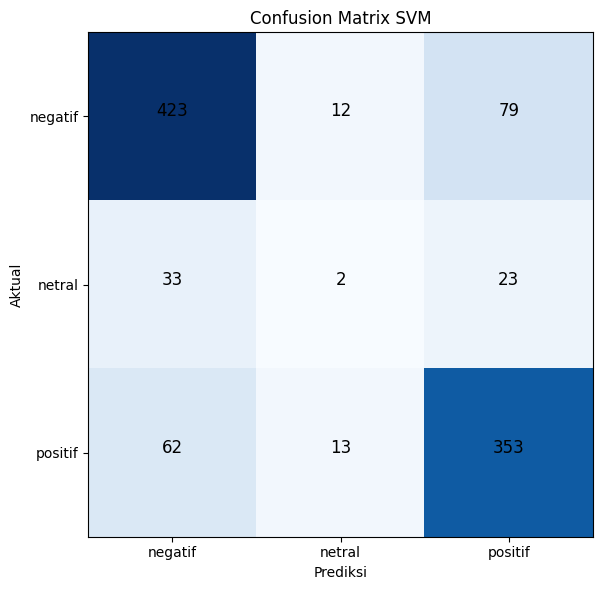

In [92]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

label = sorted(df_model["sentimen"].unique())

cm = confusion_matrix(
    y_test,
    y_pred,
    labels=label
)

cm_df = pd.DataFrame(
    cm,
    index=label,
    columns=label
)

display(cm_df)

cm_df.to_excel(
    OUTPUT_DIR+"/Confusion_Matrix.xlsx"
)

fig,ax=plt.subplots(figsize=(7,6))

im=ax.imshow(cm,cmap="Blues")

ax.set_xticks(range(len(label)))
ax.set_yticks(range(len(label)))

ax.set_xticklabels(label)
ax.set_yticklabels(label)

for i in range(len(label)):
    for j in range(len(label)):
        ax.text(j,i,cm[i,j],ha="center",fontsize=12)

plt.xlabel("Prediksi")
plt.ylabel("Aktual")
plt.title("Confusion Matrix SVM")

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR+"/Confusion_Matrix.png",
    dpi=300
)

plt.show()

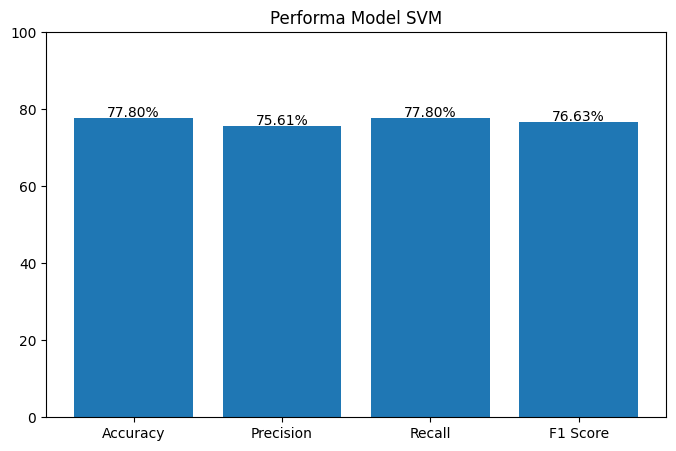

In [93]:
fig,ax=plt.subplots(figsize=(8,5))

ax.bar(
    hasil_model["Metric"],
    hasil_model["Nilai (%)"]
)

for i,v in enumerate(hasil_model["Nilai (%)"]):
    ax.text(i,v+0.3,f"{v:.2f}%",ha="center")

plt.ylim(0,100)

plt.title("Performa Model SVM")

plt.savefig(
    OUTPUT_DIR+"/Grafik_Performa_Model.png",
    dpi=300
)

plt.show()

  NB-5 : KLASIFIKASI SVM — LEXICON InSet
📊 Data model (dengan netral): 5,000
   Positif : 2,141
   Negatif : 2,568
   Netral  : 291

═════════════════════════════════════════════════════════════════
  SKENARIO 70:30
═════════════════════════════════════════════════════════════════
  Train: 3,500
  Test : 1,500
  Fitur TF-IDF: 5,000

  [GridSearchCV cv=3]
  🔍 [Linear] ... ✓ CV Acc=0.7529 (48.7s)
     → {'svc__C': 1, 'svc__kernel': 'linear'}
  🔍 [RBF] ... ✓ CV Acc=0.7577 (43.7s)
     → {'svc__C': 10, 'svc__gamma': 0.1, 'svc__kernel': 'rbf'}
  🔍 [Polynomial] ... ✓ CV Acc=0.7063 (51.3s)
     → {'svc__C': 10, 'svc__degree': 2, 'svc__kernel': 'poly'}
  🔍 [Sigmoid] ... ✓ CV Acc=0.7526 (37.5s)
     → {'svc__C': 10, 'svc__gamma': 0.1, 'svc__kernel': 'sigmoid'}

★ Kernel Terbaik: RBF | CV Acc=0.7577

Test Set
Accuracy : 0.7747
Precision: 0.7326
Recall   : 0.7747
F1-Score : 0.7529
              precision    recall  f1-score   support

     negatif       0.78      0.85      0.81       771
      ne

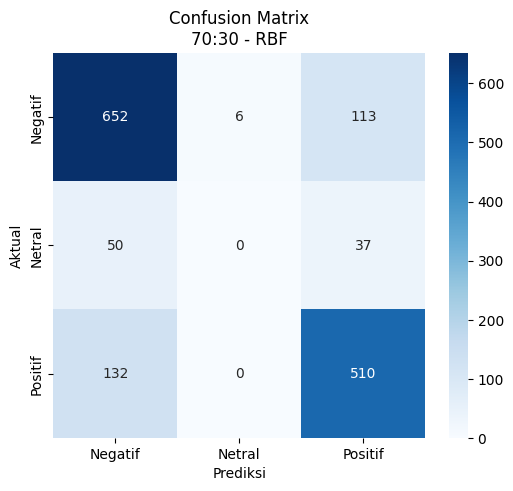


[K-Fold Validation]
k=5 | Acc=0.7900 | Prec=0.7636 | Rec=0.7900 | F1=0.7697
k=10 | Acc=0.7964 | Prec=0.7669 | Rec=0.7964 | F1=0.7753

═════════════════════════════════════════════════════════════════
  SKENARIO 80:20
═════════════════════════════════════════════════════════════════
  Train: 4,000
  Test : 1,000
  Fitur TF-IDF: 5,000

  [GridSearchCV cv=3]
  🔍 [Linear] ... ✓ CV Acc=0.7685 (39.4s)
     → {'svc__C': 1, 'svc__kernel': 'linear'}
  🔍 [RBF] ... ✓ CV Acc=0.7700 (56.7s)
     → {'svc__C': 10, 'svc__gamma': 0.1, 'svc__kernel': 'rbf'}
  🔍 [Polynomial] ... ✓ CV Acc=0.7213 (66.6s)
     → {'svc__C': 10, 'svc__degree': 2, 'svc__kernel': 'poly'}
  🔍 [Sigmoid] ... ✓ CV Acc=0.7688 (48.4s)
     → {'svc__C': 1, 'svc__gamma': 'scale', 'svc__kernel': 'sigmoid'}

★ Kernel Terbaik: RBF | CV Acc=0.7700

Test Set
Accuracy : 0.7960
Precision: 0.7643
Recall   : 0.7960
F1-Score : 0.7751
              precision    recall  f1-score   support

     negatif       0.81      0.85      0.83       514
   

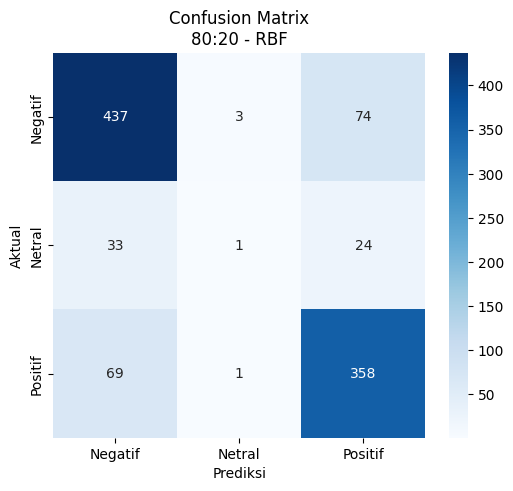


[K-Fold Validation]
k=5 | Acc=0.7888 | Prec=0.7635 | Rec=0.7888 | F1=0.7684
k=10 | Acc=0.7978 | Prec=0.7695 | Rec=0.7978 | F1=0.7770

═════════════════════════════════════════════════════════════════
  SKENARIO 90:10
═════════════════════════════════════════════════════════════════
  Train: 4,500
  Test : 500
  Fitur TF-IDF: 5,000

  [GridSearchCV cv=3]
  🔍 [Linear] ... ✓ CV Acc=0.7678 (50.4s)
     → {'svc__C': 1, 'svc__kernel': 'linear'}
  🔍 [RBF] ... ✓ CV Acc=0.7727 (69.7s)
     → {'svc__C': 10, 'svc__gamma': 0.1, 'svc__kernel': 'rbf'}
  🔍 [Polynomial] ... ✓ CV Acc=0.7213 (85.5s)
     → {'svc__C': 10, 'svc__degree': 2, 'svc__kernel': 'poly'}
  🔍 [Sigmoid] ... ✓ CV Acc=0.7678 (60.8s)
     → {'svc__C': 10, 'svc__gamma': 0.1, 'svc__kernel': 'sigmoid'}

★ Kernel Terbaik: RBF | CV Acc=0.7727

Test Set
Accuracy : 0.7780
Precision: 0.7343
Recall   : 0.7780
F1-Score : 0.7554
              precision    recall  f1-score   support

     negatif       0.78      0.85      0.81       257
      ne

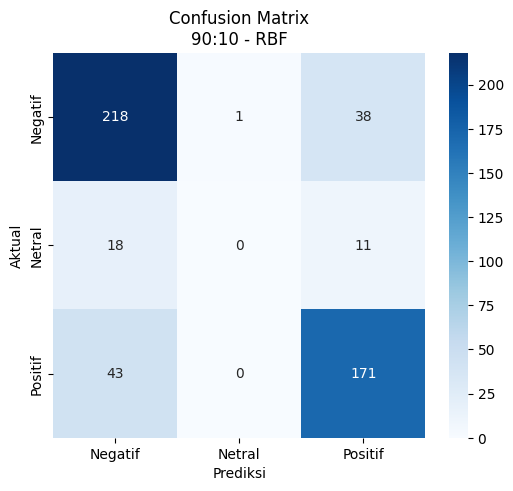


[K-Fold Validation]
k=5 | Acc=0.7874 | Prec=0.7619 | Rec=0.7874 | F1=0.7666
k=10 | Acc=0.7968 | Prec=0.7732 | Rec=0.7968 | F1=0.7756

✅ Semua skenario selesai diproses.


In [73]:
# ┌─────────────────────────────────────────────────────────────────────────┐
# │ NB-5 : KLASIFIKASI SVM — LEXICON InSet (VERSI CEPAT)                   │
# └─────────────────────────────────────────────────────────────────────────┘

print("=" * 65)
print("  NB-5 : KLASIFIKASI SVM — LEXICON InSet")
print("=" * 65)

# Include all sentiments (positif, negatif, netral)
df_model = df_raw.copy().reset_index(drop=True)

print(f"📊 Data model (dengan netral): {len(df_model):,}")
print(f"   Positif : {(df_model['sentimen']=='positif').sum():,}")
print(f"   Negatif : {(df_model['sentimen']=='negatif').sum():,}")
print(f"   Netral  : {(df_model['sentimen']=='netral').sum():,}")

X_all = df_model["text_preprocessed"].values
y_all = df_model["sentimen"].values

# ── Parameter Grid (diperkecil agar cepat) ───────────────────────────────
def get_param_grids():
    return {

        "Linear": {
            "svc__kernel": ["linear"],
            "svc__C": [0.1, 1, 10]
        },

        "RBF": {
            "svc__kernel": ["rbf"],
            "svc__C": [1, 10],
            "svc__gamma": ["scale", 0.1]
        },

        "Polynomial": {
            "svc__kernel": ["poly"],
            "svc__C": [1, 10],
            "svc__degree": [2, 3]
        },

        "Sigmoid": {
            "svc__kernel": ["sigmoid"],
            "svc__C": [1, 10],
            "svc__gamma": ["scale", 0.1]
        }
    }


# ── GridSearch ────────────────────────────────────────────────────────────
def run_gridsearch(X_vec, y, cv=3):

    results = {}

    for kernel_name, params in get_param_grids().items():

        print(f"  🔍 [{kernel_name}] ...", end=" ", flush=True)

        start = time.time()

        pipe = Pipeline([
            ("svc", SVC(random_state=RANDOM_STATE))
        ])

        gs = GridSearchCV(
            estimator=pipe,
            param_grid=params,
            cv=cv,
            scoring="accuracy",
            n_jobs=-1,
            verbose=0
        )

        gs.fit(X_vec, y)

        elapsed = time.time() - start

        print(
            f"✓ CV Acc={gs.best_score_:.4f} "
            f"({elapsed:.1f}s)"
        )

        print(f"     → {gs.best_params_}")

        results[kernel_name] = {
            "estimator": gs.best_estimator_,
            "params": gs.best_params_,
            "cv_acc": gs.best_score_
        }

    return results


# ── Penyimpanan hasil ─────────────────────────────────────────────────────
all_gs_rows = []
all_eval_rows = []
all_kfold_rows = []

KFOLD_LIST = [5, 10]

for split_name, test_size in SPLITS.items():

    print(f"\n{'═'*65}")
    print(f"  SKENARIO {split_name}")
    print(f"{'═'*65}")

    X_tr, X_te, y_tr, y_te = train_test_split(
        X_all,
        y_all,
        test_size=test_size,
        random_state=RANDOM_STATE,
        stratify=y_all
    )

    print(f"  Train: {len(X_tr):,}")
    print(f"  Test : {len(X_te):,}")

    # TF-IDF
    tfidf = TfidfVectorizer(
        max_features=5000,
        ngram_range=(1, 2),
        sublinear_tf=True
    )

    X_tr_vec = tfidf.fit_transform(X_tr)
    X_te_vec = tfidf.transform(X_te)

    print(f"  Fitur TF-IDF: {X_tr_vec.shape[1]:,}")

    # GridSearch
    print("\n  [GridSearchCV cv=3]")
    gs_res = run_gridsearch(X_tr_vec, y_tr, cv=3)

    for ker, res in gs_res.items():
        all_gs_rows.append({
            "Skenario": split_name,
            "Kernel": ker,
            "Best Params": str(res["params"]),
            "CV Accuracy": round(res["cv_acc"], 4)
        })

    # Kernel terbaik
    best_kname = max(
        gs_res,
        key=lambda k: gs_res[k]["cv_acc"]
    )

    best_model = gs_res[best_kname]["estimator"]

    print(
        f"\n★ Kernel Terbaik: {best_kname}"
        f" | CV Acc={gs_res[best_kname]['cv_acc']:.4f}"
    )

    # Evaluasi Test Set
    y_pred = best_model.predict(X_te_vec)

    acc = accuracy_score(y_te, y_pred)
    # Changed to 'weighted' average for multi-class
    prec = precision_score(
        y_te, y_pred,
        average="weighted",
        zero_division=0
    )
    rec = recall_score(
        y_te, y_pred,
        average="weighted",
        zero_division=0
    )
    f1 = f1_score(
        y_te, y_pred,
        average="weighted",
        zero_division=0
    )

    print(
        f"\nTest Set"
        f"\nAccuracy : {acc:.4f}"
        f"\nPrecision: {prec:.4f}"
        f"\nRecall   : {rec:.4f}"
        f"\nF1-Score : {f1:.4f}"
    )

    target_names_list = sorted(df_model['sentimen'].unique())
    print(
        classification_report(
            y_te,
            y_pred,
            target_names=target_names_list
        )
    )

    all_eval_rows.append({
        "Skenario": split_name,
        "Kernel": best_kname,
        "Accuracy": round(acc, 4),
        "Precision": round(prec, 4),
        "Recall": round(rec, 4),
        "F1-Score": round(f1, 4)
    })

    # Confusion Matrix Test Set
    cm = confusion_matrix(
        y_te,
        y_pred,
        labels=target_names_list
    )

    plt.figure(figsize=(6, 5))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=[s.capitalize() for s in target_names_list],
        yticklabels=[s.capitalize() for s in target_names_list]
    )

    plt.title(
        f"Confusion Matrix\n{split_name} - {best_kname}"
    )

    plt.xlabel("Prediksi")
    plt.ylabel("Aktual")
    plt.show()

    # K-Fold
    print("\n[K-Fold Validation]")

    X_all_vec = tfidf.transform(X_all)

    for k in KFOLD_LIST:

        skf = StratifiedKFold(
            n_splits=k,
            shuffle=True,
            random_state=RANDOM_STATE
        )

        y_cv = cross_val_predict(
            best_model,
            X_all_vec,
            y_all,
            cv=skf,
            n_jobs=-1
        )

        k_acc = accuracy_score(y_all, y_cv)
        # Changed to 'weighted' average for multi-class
        k_prec = precision_score(
            y_all,
            y_cv,
            average="weighted",
            zero_division=0
        )
        k_rec = recall_score(
            y_all,
            y_cv,
            average="weighted",
            zero_division=0
        )
        k_f1 = f1_score(
            y_all,
            y_cv,
            average="weighted",
            zero_division=0
        )

        print(
            f"k={k} | "
            f"Acc={k_acc:.4f} | "
            f"Prec={k_prec:.4f} | "
            f"Rec={k_rec:.4f} | "
            f"F1={k_f1:.4f}"
        )

        all_kfold_rows.append({
            "Skenario": split_name,
            "Kernel": best_kname,
            "k": k,
            "Accuracy": round(k_acc, 4),
            "Precision": round(k_prec, 4),
            "Recall": round(k_rec, 4),
            "F1-Score": round(k_f1, 4)
        })

print("\n✅ Semua skenario selesai diproses.")

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import confusion_matrix
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV

# Reuse definitions from previous cells for consistency
# df_raw is already available in the kernel state
# PAL is also available

# Define the get_param_grids and run_gridsearch functions again for clarity
def get_param_grids():
    return {
        "Linear": {
            "svc__kernel": ["linear"],
            "svc__C": [0.1, 1, 10]
        },
        "RBF": {
            "svc__kernel": ["rbf"],
            "svc__C": [1, 10],
            "svc__gamma": ["scale", 0.1]
        },
        "Polynomial": {
            "svc__kernel": ["poly"],
            "svc__C": [1, 10],
            "svc__degree": [2, 3]
        },
        "Sigmoid": {
            "svc__kernel": ["sigmoid"],
            "svc__C": [1, 10],
            "svc__gamma": ["scale", 0.1]
        }
    }

def run_gridsearch_reproduce(X_vec, y, cv=3):
    results = {}
    for kernel_name, params in get_param_grids().items():
        pipe = Pipeline([("svc", SVC(random_state=RANDOM_STATE))])
        gs   = GridSearchCV(pipe, params, cv=cv, scoring="accuracy",
                            n_jobs=-1, verbose=0, refit=True)
        gs.fit(X_vec, y)
        results[kernel_name] = {
            "estimator": gs.best_estimator_,
            "params"   : gs.best_params_,
            "cv_acc"   : gs.best_score_,
        }
    return results

# Prepare data as in cell uEvtjoxRI3bt
df_model = df_raw.copy().reset_index(drop=True)
X_all = df_model["text_preprocessed"].values
y_all = df_model["sentimen"].values
target_names_list = sorted(df_model['sentimen'].unique()) # ['negatif', 'netral', 'positif']

print("Generating Confusion Matrices for each scenario...")
for split_name, test_size in SPLITS.items():
    print(f"\nDisplaying Confusion Matrix for Skenario {split_name}...")

    X_tr, X_te, y_tr, y_te = train_test_split(
        X_all,
        y_all,
        test_size=test_size,
        random_state=RANDOM_STATE,
        stratify=y_all
    )

    tfidf = TfidfVectorizer(
        max_features=5000,
        ngram_range=(1, 2),
        sublinear_tf=True
    )

    X_tr_vec = tfidf.fit_transform(X_tr)
    X_te_vec = tfidf.transform(X_te)

    # Re-run grid search to get the best model for this split, as parameters were tuned per split
    gs_res = run_gridsearch_reproduce(X_tr_vec, y_tr, cv=3)

    best_kname = max(gs_res, key=lambda k: gs_res[k]["cv_acc"])
    best_model = gs_res[best_kname]["estimator"]

    y_pred = best_model.predict(X_te_vec)

    # Confusion Matrix Test Set
    cm = confusion_matrix(
        y_te,
        y_pred,
        labels=target_names_list
    )

    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=[s.capitalize() for s in target_names_list],
        yticklabels=[s.capitalize() for s in target_names_list]
    )
    plt.title(
        f"Confusion Matrix\n{split_name} - {best_kname}"
    )
    plt.xlabel("Prediksi")
    plt.ylabel("Aktual")
    plt.show()

print("\nAll requested Confusion Matrices displayed.")


In [ ]:
import pandas as pd
# ┌─────────────────────────────────────────────────────────────────────────┐
# │ CELL 15 ─  VISUALISASI EVALUASI (VIZ 6b Bar Chart, 6c Line Chart)       │
# └─────────────────────────────────────────────────────────────────────────┘
# %%

df_eval   = pd.DataFrame(all_eval_rows)
df_kfold  = pd.DataFrame(all_kfold_rows)
df_gs_sum = pd.DataFrame(all_gs_rows)

# ── TABEL 10: Nilai pengujian 3 skenario ─────────────────────────────────
print("=" * 65)
print("📋 TABEL 10: NILAI PENGUJIAN 3 SKENARIO PEMBAGIAN DATA")
print("=" * 65)
display(
    df_eval.style
    .background_gradient(subset=["Accuracy","Precision","Recall","F1-Score"],
                          cmap="Greens")
    .format({"Accuracy":"{:.4f}","Precision":"{:.4f}",
             "Recall":"{:.4f}","F1-Score":"{:.4f}"})
    .set_table_styles([
        {"selector":"th","props":[("background",PAL["primary"]),("color","white")]},
    ])
    .hide(axis="index")
)

# ── VIZ 6b: Bar Chart Metrik Evaluasi ────────────────────────────────────
metrics    = ["Accuracy","Precision","Recall","F1-Score"]
x          = np.arange(len(metrics))
width      = 0.26
bar_colors = [PAL["primary"],"#00838F","#558B2F"]

fig, ax = plt.subplots(figsize=(12, 5.5), facecolor=PAL["bg"])
for i, row in df_eval.iterrows():
    vals = [row[m] for m in metrics]
    bars = ax.bar(x + i*width, vals, width,
                  label=f"{row['Skenario']} ({row['Kernel']})",
                  color=bar_colors[i], alpha=0.88, edgecolor="white")
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.006,
                f"{v:.4f}", ha="center", va="bottom", fontsize=7.5,
                fontweight="bold")

ax.set_xticks(x + width)
ax.set_xticklabels(metrics, fontsize=11)
ax.set_ylim(0, 1.12)
ax.set_ylabel("Score", fontsize=11)
ax.set_title("Perbandingan Metrik Evaluasi Model SVM per Skenario",
             fontsize=13, fontweight="bold")
ax.legend(title="Skenario (Kernel)", fontsize=10)
ax.grid(axis="y", alpha=0.3, linestyle="--")
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/viz6b_bar_metrik_skenario.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Viz 6b: Bar chart metrik tersimpan.")

# ── VIZ 6c: Line Chart K-Fold per Skenario ────────────────────────────────
n_sp  = len(SPLITS)
fig, axes = plt.subplots(1, n_sp, figsize=(7*n_sp, 5.5),
                          facecolor=PAL["bg"], sharex=True, sharey=True)
fig.suptitle("Performa K-Fold Cross Validation per Skenario",
             fontsize=14, fontweight="bold")
met_colors = {"Accuracy":PAL["primary"],"Precision":"#00838F",
              "Recall":"#E65100","F1-Score":"#6A1B9A"}

for ax, split_name in zip(axes, SPLITS.keys()):
    sub = df_kfold[df_kfold["Skenario"]==split_name]
    for met, col in met_colors.items():
        ax.plot(sub["k"], sub[met], marker="o", linewidth=2.3,
                color=col, label=met, markersize=7)
        for _, row in sub.iterrows():
            ax.annotate(f"{row[met]:.3f}", (row["k"], row[met]),
                        textcoords="offset points", xytext=(0,6),
                        ha="center", fontsize=7, color=col)
    ax.set_title(f"Skenario {split_name}", fontsize=12, fontweight="bold")
    ax.set_xlabel("Jumlah Fold (k)"); ax.set_ylabel("Score")
    ax.set_xticks(KFOLD_LIST); ax.set_ylim(0.50, 1.08)
    ax.grid(True, alpha=0.3, linestyle="--")
    ax.legend(fontsize=8, loc="lower right")
    ax.spines[["top","right"]].set_visible(False)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/viz6c_linechart_kfold.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Viz 6c: Line chart K-Fold tersimpan.")


In [ ]:
# ┌─────────────────────────────────────────────────────────────────────┐
# │ VISUALISASI KEMIRIPAN (SIMILARITY) ANTAR TWEET                     │
# └─────────────────────────────────────────────────────────────────────┘

print("=" * 65)
print("VISUALISASI SIMILARITY ANTAR TWEET")
print("=" * 65)

from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity

sample_size = min(300, len(df_raw))

df_sim = df_raw.sample(
    n=sample_size,
    random_state=RANDOM_STATE
).copy()

tfidf_sim = TfidfVectorizer(
    max_features=3000,
    ngram_range=(1,2)
)

X_sim = tfidf_sim.fit_transform(df_sim["text_clean"])

# Cosine Similarity Matrix
sim_matrix = cosine_similarity(X_sim)

print(f"Shape similarity matrix : {sim_matrix.shape}")

# PCA untuk visualisasi
pca = PCA(n_components=2)
coords = pca.fit_transform(X_sim.toarray())

plt.figure(figsize=(10,8))

plt.scatter(
    coords[:,0],
    coords[:,1],
    alpha=0.7,
    s=40
)

plt.title(
    "Peta Kemiripan Tweet (PCA + TF-IDF)",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/SMILIARITYANTARTWEET.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
# ┌─────────────────────────────────────────────────────────────────────┐
# │ HEATMAP COSINE SIMILARITY                                           │
# └─────────────────────────────────────────────────────────────────────┘

print("=" * 65)
print("HEATMAP COSINE SIMILARITY")
print("=" * 65)

subset = min(50, len(df_sim))

plt.figure(figsize=(12,10))

sns.heatmap(
    sim_matrix[:subset,:subset],
    cmap="YlGnBu"
)

plt.title(
    f"Heatmap Similarity {subset} Tweet Sampel"
)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/HEATMAPSMILIARITY.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
# ┌─────────────────────────────────────────────────────────────────────┐
# │ PERBANDINGAN SEMUA KERNEL                                           │
# └─────────────────────────────────────────────────────────────────────┘

kernel_rows = []

for kernel_name, res in gs_res.items():

    model = res["estimator"]

    y_pred = model.predict(X_te_vec)

    # Updated for multi-class: using average='weighted' instead of pos_label='positif'
    kernel_rows.append({
        "Kernel": kernel_name,
        "CV Accuracy": round(res["cv_acc"], 4),
        "Accuracy": round(
            accuracy_score(y_te, y_pred), 4
        ),
        "Precision": round(
            precision_score(
                y_te,
                y_pred,
                average="weighted",
                zero_division=0
            ), 4
        ),
        "Recall": round(
            recall_score(
                y_te,
                y_pred,
                average="weighted",
                zero_division=0
            ), 4
        ),
        "F1-Score": round(
            f1_score(
                y_te,
                y_pred,
                average="weighted",
                zero_division=0
            ), 4
        )
    })

kernel_df = pd.DataFrame(kernel_rows)

print("📊 PERBANDINGAN SELURUH KERNEL")
display(kernel_df.sort_values("F1-Score", ascending=False))
kernel_df.to_excel(f"{OUTPUT_DIR}/perbandinganseluruhkernel.xlsx", index=False)

In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=kernel_df.sort_values(
        "F1-Score",
        ascending=False
    ),
    x="Kernel",
    y="F1-Score"
)

plt.title("Perbandingan F1-Score Semua Kernel")

for i, v in enumerate(
    kernel_df.sort_values(
        "F1-Score",
        ascending=False
    )["F1-Score"]
):
    plt.text(
        i,
        v + 0.01,
        f"{v:.3f}",
        ha="center"
    )

plt.ylim(0,1)
plt.show()
save_path = f"{OUTPUT_DIR}/perbandinganf1score.png"

In [ ]:
# ┌─────────────────────────────────────────────────────────────┐
# │ TABEL PERSENTASE HASIL KLASIFIKASI SENTIMEN                │
# └─────────────────────────────────────────────────────────────┘

hasil_sentimen = []

for split_name, test_size in SPLITS.items():

    X_tr, X_te, y_tr, y_te = train_test_split(
        X_all,
        y_all,
        test_size=test_size,
        random_state=RANDOM_STATE,
        stratify=y_all
    )

    tfidf = TfidfVectorizer(
        max_features=5000,
        ngram_range=(1,2),
        sublinear_tf=True
    )

    X_tr_vec = tfidf.fit_transform(X_tr)
    X_te_vec = tfidf.transform(X_te)

    gs_res = run_gridsearch(
        X_tr_vec,
        y_tr,
        cv=3
    )

    best_kernel = max(
        gs_res,
        key=lambda x: gs_res[x]["cv_acc"]
    )

    model = gs_res[best_kernel]["estimator"]

    y_pred = model.predict(X_te_vec)

    total = len(y_pred)

    pos_pct = (y_pred == "positif").sum() / total * 100
    neg_pct = (y_pred == "negatif").sum() / total * 100
    net_pct = (y_pred == "netral").sum() / total * 100

    hasil_sentimen.append({
        "Skenario": split_name,
        "Kernel Terbaik": best_kernel,
        "Positif (%)": round(pos_pct, 2),
        "Negatif (%)": round(neg_pct, 2),
        "Netral (%)": round(net_pct, 2)
    })

hasil_sentimen_df = pd.DataFrame(hasil_sentimen)

display(hasil_sentimen_df)

save_path = f"{OUTPUT_DIR}/tabel_persentase_sentimen.xlsx"

hasil_sentimen_df.to_excel(
    save_path,
    index=False
)

print(f"✅ Tersimpan: {save_path}")

In [ ]:
# ┌─────────────────────────────────────────────────────────────────────┐
# │ DETEKSI TWEET MIRIP (SAMPLE 1000 TWEET)                             │
# └─────────────────────────────────────────────────────────────────────┘

import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neighbors import NearestNeighbors

print("=" * 65)
print("DETEKSI TWEET MIRIP (100 SAMPLE)")
print("=" * 65)

# Pastikan df_raw sudah didefinisikan di cell sebelumnya
try:
    # Ambil 1000 tweet acak
    sample_df = (
        df_raw
        .sample(
            n=min(1000, len(df_raw)),
            random_state=42
        )
        .reset_index(drop=True)
    )

    texts = sample_df["text_clean"].fillna("").astype(str)

    print(f"Jumlah sampel: {len(sample_df)}")

    # TF-IDF
    vectorizer = TfidfVectorizer(
        max_features=3000,
        ngram_range=(1,2)
    )

    X = vectorizer.fit_transform(texts)

    # Nearest Neighbor
    nn = NearestNeighbors(
        n_neighbors=5,
        metric="cosine"
    )

    nn.fit(X)

    distances, indices = nn.kneighbors(X)

    similar_rows = []

    THRESHOLD = 0.50

    for i in range(len(texts)):
        for rank in range(1, 5):
            similarity = 1 - distances[i][rank]
            if similarity >= THRESHOLD:
                j = indices[i][rank]
                if i < j:
                    similar_rows.append({
                        "Tweet_ID_1": i,
                        "Tweet_ID_2": j,
                        "Similarity": round(similarity, 4),
                        "Tweet_1": texts.iloc[i],
                        "Tweet_2": texts.iloc[j]
                    })

    similar_df = pd.DataFrame(similar_rows)
    similar_df = similar_df.sort_values("Similarity", ascending=False)

    print(f"Pasangan tweet mirip ditemukan: {len(similar_df)}")
    display(similar_df.head(20))

    # Simpan
    similar_df.to_excel(
        f"{OUTPUT_DIR}/tweet_mirip_100sample.xlsx",
        index=False
    )
    print("✅ File tersimpan")

except NameError as e:
    print("❌ Error: Variabel 'df_raw' belum ada. Silakan jalankan cell Preprocessing (Cell 5 & 6) terlebih dahulu.")

In [ ]:
# ┌─────────────────────────────────────────────────────────────────────┐
# │ CONNECTED GRAPH TWEET MIRIP (100 SAMPLE)                           │
# └─────────────────────────────────────────────────────────────────────┘

import networkx as nx

G = nx.Graph()

# Ambil maksimal 50 relasi terkuat
top_edges = similar_df.head(50)

for _, row in top_edges.iterrows():

    G.add_edge(
        str(row["Tweet_ID_1"]),
        str(row["Tweet_ID_2"]),
        weight=row["Similarity"]
    )

plt.figure(figsize=(12,10))

pos = nx.spring_layout(
    G,
    seed=42,
    k=0.8
)

nx.draw_networkx_nodes(
    G,
    pos,
    node_size=300
)

nx.draw_networkx_edges(
    G,
    pos,
    alpha=0.5
)

nx.draw_networkx_labels(
    G,
    pos,
    font_size=8
)

plt.title(
    "Connected Graph Kemiripan Tweet (100 Sampel)"
)

plt.axis("off")

plt.savefig(
    f"{OUTPUT_DIR}/connected_graph_100sample.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("✅ Connected graph tersimpan")

In [ ]:
# ┌─────────────────────────────────────────────────────────────────────────┐
# │ CELL 16 ─  SIMPAN SEMUA TABEL & VISUALISASI KE DOWNLOAD                │
# └─────────────────────────────────────────────────────────────────────────┘

import os
from google.colab import files

# 1. Simpan Semua Tabel ke Excel
out_excel = f"{OUTPUT_DIR}/RINGKASAN_HASIL_LENGKAP.xlsx"
with pd.ExcelWriter(out_excel, engine="openpyxl") as writer:
    # Tabel Evaluasi & Model
    if 'df_eval' in globals():
        df_eval.to_excel(writer,      sheet_name="Tabel10_Skenario",     index=False)
    if 'df_kfold' in globals():
        df_kfold.to_excel(writer,     sheet_name="KFold_Results",        index=False)
    if 'df_gs_sum' in globals():
        df_gs_sum.to_excel(writer,    sheet_name="GridSearch_Params",    index=False)
    if 'kernel_df' in globals():
        kernel_df.to_excel(writer,    sheet_name="Perbandingan_Kernel",  index=False)
    if 'hasil_sentimen_df' in globals():
        hasil_sentimen_df.to_excel(writer, sheet_name="Persentase_Sentimen", index=False)

    # Tabel Preprocessing & Data
    if 'df_tfidf' in globals():
        df_tfidf.to_excel(writer,     sheet_name="Tabel8_TFIDF",         index=False)
    if 'steps_all' in globals():
        steps_all.to_excel(writer,    sheet_name="Tabel7_Preprocessing", index=False)
    if 'tabel_sample' in globals():
        tabel_sample.to_excel(writer, sheet_name="Viz2_Sampel_Tweet",    index=False)
    if 'dist' in globals():
        dist.reset_index().rename(columns={"index":"Sentimen","sentimen":"Jumlah"}).to_excel(
            writer, sheet_name="Distribusi_Sentimen", index=False)

    # Tabel Similarity
    if 'similar_df' in globals():
        similar_df.to_excel(writer, sheet_name="Deteksi_Tweet_Mirip", index=False)

print(f"✅ Semua tabel yang tersedia tersimpan → {out_excel}")

# 2. Kompres Semua Visualisasi (PNG) ke ZIP
zip_path = "/content/semua_output_visualisasi.zip"
!zip -j -q {zip_path} {OUTPUT_DIR}/*.png {out_excel}

print(f"ፀ File ZIP siap diunduh: {zip_path}")

# 3. Download
files.download(zip_path)

In [ ]:
# ┌─────────────────────────────────────────────────────────────────────────┐
# │ CELL 17 ─  RINGKASAN AKHIR                                              │
# └─────────────────────────────────────────────────────────────────────────┘
# %%

print("\n" + "╔" + "═"*67 + "╗")
print("║  ✅  ANALISIS SELESAI — RINGKASAN LENGKAP OUTPUT                    ║")
print("╚" + "═"*67 + "╝")

print(f"""
📁 Output folder : {OUTPUT_DIR}/

┌─ DICTIONARY (diunduh otomatis dari GitHub) ─────────────────────────┐
│  ✅ Colloquial Indonesian Lexicon  → nasalsabila/kamus-alay          │
│  ✅ ID-Stopwords                   → masdevid/ID-Stopwords           │
│  ✅ InSet Lexicon                  → upload manual (fajri91/InSet)   │
│  ✗  SentiStrength                 → dilewati (sesuai permintaan)     │
└──────────────────────────────────────────────────────────────────────┘

┌─ VISUALISASI ────────────────────────────────────────────────────────┐
│  viz1_donut_distribusi.png          Distribusi kelas sentimen        │
│  viz3_tren_waktu.png                Tren sentimen per bulan          │
│  viz4_wordcloud.png                 WordCloud per kelas              │
│  viz5_top10_kata.png                Top-10 kata (term frequency)     │
│  viz6a_cm_*.png                     Confusion matrix uji (×3)        │
│  viz6b_bar_metrik_skenario.png      Bar chart metrik evaluasi        │
│  viz6c_linechart_kfold.png          Line chart K-Fold                │
│  viz9a_kfold_k*.png                 Ilustrasi visual K-Fold          │
│  viz9b_cm_kfold_*.png               CM K-Fold (k=5,10,15,20 ×3)    │
└──────────────────────────────────────────────────────────────────────┘

┌─ TABEL (RINGKASAN_HASIL_LENGKAP.xlsx) ──────────────────────────────┐
│  Tabel7_Preprocessing    Before/after setiap tahap (1 tweet)        │
│  Tabel8_TFIDF            Perhitungan TF, IDF, TF-IDF                │
│  Viz2_Sampel_Tweet       10 sampel tweet berlabel                   │
│  Distribusi_Sentimen     Jumlah & % per kelas                       │
│  GridSearch_4Kernel      Hasil tuning semua kernel                  │
│  Tabel10_3Skenario       Nilai evaluasi 3 skenario split            │
│  KFold_Results           K-Fold (k=5,10,15,20) semua skenario      │
└──────────────────────────────────────────────────────────────────────┘

  Penyusun : Virgy Septiana (220660121104) — UNSAP
  Referensi: lailikanabila/ANALISIS-SENTIMEN-IKN-SVM (GitHub)
""")